In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

## S

- s / average / inverse_transform

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from data_provider.icecore_data_loader import Dataset_IceCore_S
from utils.metrics import (
    metric,
    pearson_corr,
    trend_corr,
    direction_accuracy,
    lag_aware_corr,
    smooth_corr,
    a3_corr,
    peak_event_metrics,
)
print("PROJECT_ROOT =", PROJECT_ROOT)

def _to_str_array(arr):
    """
    兼容 npz 里 sites 可能是 bytes / object / str 的情况。
    """
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out)


def _safe_inverse_transform(dataset, vals):
    """
    使用 Dataset_IceCore_S 自带 inverse_transform 做反归一化。
    vals: list / np.array, shape [N]
    return: np.array, shape [N]
    """
    if vals is None or len(vals) == 0:
        return np.array([])

    vals = np.asarray(vals, dtype=np.float32).reshape(-1, 1)
    vals_inv = dataset.inverse_transform(vals)
    return vals_inv.reshape(-1)




def _calc_prediction_metrics(pred_values, true_values):
    # 和 test() 使用同一套指标，输入保持为反归一化之前的值。
    # pred_values / true_values: [N, T] 或 [N, T, C]
    pred_values = np.asarray(pred_values)
    true_values = np.asarray(true_values)

    mae, mse, rmse, mape, mspe = metric(pred_values, true_values)
    corr = pearson_corr(pred_values, true_values)
    trend_corr_value = trend_corr(pred_values, true_values)
    direction_acc = direction_accuracy(pred_values, true_values)
    lag_corr, best_lag = lag_aware_corr(pred_values, true_values, max_lag=2)
    corr_smooth_3 = smooth_corr(pred_values, true_values, window=3)
    a3_corr_value = a3_corr(pred_values, true_values)
    peak_recall, peak_precision, peak_f1 = peak_event_metrics(
        pred_values,
        true_values,
        top_ratio=0.1,
        lag_window=2,
    )

    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "mspe": mspe,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "a3_corr": a3_corr_value,
        "trend_corr": trend_corr_value,
        "direction_acc": direction_acc,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "peak_recall_10_lag2": peak_recall,
        "peak_precision_10_lag2": peak_precision,
        "peak_f1_10_lag2": peak_f1,
    }


def _print_site_prediction_metrics(site_name, metrics, stage="metrics"):
    # 打印单个被绘制站点的指标，数值来自反归一化之前的 preds/trues。
    print(
        f"Site {site_name} {stage} | "
        f"mse={metrics['mse']:.4f}, mae={metrics['mae']:.4f}, "
        f"corr={metrics['corr']:.4f}, "
        f"corr_smooth_3={metrics['corr_smooth_3']:.4f}, "
        f"a3_corr={metrics['a3_corr']:.4f}, "
        f"trend_corr={metrics['trend_corr']:.4f}, "
        f"direction_acc={metrics['direction_acc'] * 100:.1f}%, "
        f"lag_corr@±2={metrics['lag_corr']:.4f}, "
        f"best_lag={metrics['best_lag']}, "
        f"PeakRecall@10%_±2={metrics['peak_recall_10_lag2']:.4f}, "
        f"PeakPrecision@10%_±2={metrics['peak_precision_10_lag2']:.4f}, "
        f"PeakF1@10%_±2={metrics['peak_f1_10_lag2']:.4f}"
    )

def _calc_mean_and_sort(data_dict):
    """
    对同一年份的多个样本值求平均，并按年份排序。
    """
    if not data_dict:
        return [], []

    sorted_years = sorted(data_dict.keys())
    mean_vals = [np.mean(data_dict[y]) for y in sorted_years]
    return sorted_years, mean_vals


def visualise_icecore_s_with_history(
    npz_path,
    target_cluster,
    root_path,
    data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    save_dir=None,
    show=True,
):
    """
    适配新版 Dataset_IceCore_S 的可视化函数。

    功能：
    1. 读取 results.npz 中的 preds / trues / inputs / sites / years / clusters
    2. 对同一站点、同一年份的多个预测样本求平均
    3. 使用 Dataset_IceCore_S.inverse_transform() 反归一化
    4. 绘制历史输入、真实未来值、预测未来值

    参数：
    - npz_path: results.npz 路径
    - target_cluster: 要画的 cluster id，例如 0 / 1 / 2
    - root_path: 数据根目录，例如 "./dataset/icecore/accum"
    - data_path: 单变量 csv，例如 "accum.csv"
    - cluster_result_path: 聚类结果路径，例如 "cluster/accum_cluster_mapped.csv"
    - site_meta_path: 静态特征文件路径
    - seq_len / label_len / pred_len: 必须和训练脚本一致
    - apply_pywt: 必须和训练时一致，否则 scaler 对应的数据分布可能不一致
    - residual_prediction: 一般用于画最终预测时建议 False；如果 npz 保存的是 residual，需要按你的 test 逻辑额外加回 mean
    - save_dir: 如果不为 None，则保存图片
    - show: 是否 plt.show()
    """

    # =========================================================
    # 1. 构造 Dataset_IceCore_S，用它的 global scaler 做 inverse_transform
    # =========================================================
    dataset = Dataset_IceCore_S(
        root_path=root_path,
        data_path=data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="S",
        target="accum",
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    # =========================================================
    # 2. 读取 npz
    # =========================================================
    data = np.load(npz_path, allow_pickle=True)

    preds = data["preds"]       # expected: [N, pred_len, C]
    trues = data["trues"]       # expected: [N, pred_len, C]
    sites = _to_str_array(data["sites"])
    years = data["years"]
    clusters = data["clusters"]

    has_inputs = "inputs" in data
    inputs = data["inputs"] if has_inputs else None

    # 防止 clusters 是 shape [N, 1]
    clusters = np.asarray(clusters).reshape(-1)

    # =========================================================
    # 3. 打印 scaled 指标和反归一化后的物理量指标
    # =========================================================
    scaled_mse = np.mean((preds - trues) ** 2)
    scaled_mae = np.mean(np.abs(preds - trues))

    preds_flat = preds[:, :, -1].reshape(-1, 1)
    trues_flat = trues[:, :, -1].reshape(-1, 1)

    preds_inv = dataset.inverse_transform(preds_flat)
    trues_inv = dataset.inverse_transform(trues_flat)

    physical_mse = np.mean((preds_inv - trues_inv) ** 2)
    physical_mae = np.mean(np.abs(preds_inv - trues_inv))

    print("=" * 60)
    print(f"Scaled MSE:   {scaled_mse:.6f}")
    print(f"Scaled MAE:   {scaled_mae:.6f}")
    print(f"Physical MSE: {physical_mse:.6f}")
    print(f"Physical MAE: {physical_mae:.6f}")
    print("=" * 60)

    # 每个 cluster 的物理量指标
    for cid in sorted(np.unique(clusters)):
        mask = clusters == cid
        if not np.any(mask):
            continue

        c_preds = preds[mask, :, -1].reshape(-1, 1)
        c_trues = trues[mask, :, -1].reshape(-1, 1)

        c_preds_inv = dataset.inverse_transform(c_preds)
        c_trues_inv = dataset.inverse_transform(c_trues)

        c_mse = np.mean((c_preds_inv - c_trues_inv) ** 2)
        c_mae = np.mean(np.abs(c_preds_inv - c_trues_inv))

        print(
            f"Cluster {cid}: "
            f"Samples={np.sum(mask):<4} | "
            f"Physical MSE={c_mse:.6f} | "
            f"Physical MAE={c_mae:.6f}"
        )

    print("=" * 60)

    # =========================================================
    # 4. 筛选目标 cluster
    # =========================================================
    target_indices = np.where(clusters == target_cluster)[0]

    if len(target_indices) == 0:
        print(f"❌ 未找到 Cluster {target_cluster} 的数据。")
        return

    unique_sites = np.unique(sites[target_indices])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # =========================================================
    # 5. 按站点聚合：同一年份多个样本求平均
    # =========================================================
    for site_name in unique_sites:
        site_mask = (sites == site_name) & (clusters == target_cluster)
        site_idx_list = np.where(site_mask)[0]

        agg_history = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        site_metrics = _calc_prediction_metrics(
            preds[site_idx_list, :, -1],
            trues[site_idx_list, :, -1],
        )
        _print_site_prediction_metrics(
            site_name,
            site_metrics,
            stage="pre-aggregation window scaled metrics",
        )


        for idx in site_idx_list:
            # -------------------------------------------------
            # 5.1 解析年份
            # -------------------------------------------------
            year_item = years[idx]

            # 情况 A：years[idx] 是 pred_len 个年份，例如 [1966, 1967, ...]
            if np.ndim(year_item) > 0 and len(np.asarray(year_item).reshape(-1)) > 1:
                pred_years = np.asarray(year_item).reshape(-1).astype(int)

                # 如果有 inputs，历史年份用预测起点往前推
                first_pred_year = int(pred_years[0])

            # 情况 B：years[idx] 是一个 scalar，表示预测起始年份
            else:
                first_pred_year = int(np.asarray(year_item).reshape(-1)[0])
                pred_years = np.arange(first_pred_year, first_pred_year + preds.shape[1])

            # -------------------------------------------------
            # 5.2 聚合历史输入
            # -------------------------------------------------
            if has_inputs:
                history_seq = inputs[idx, :, -1]
                cur_seq_len = len(history_seq)

                hist_years = np.arange(first_pred_year - cur_seq_len, first_pred_year)

                for yr, val in zip(hist_years, history_seq):
                    agg_history[int(yr)].append(float(val))

            # -------------------------------------------------
            # 5.3 聚合真实值和预测值
            # -------------------------------------------------
            y_true_seq = trues[idx, :, -1]
            y_pred_seq = preds[idx, :, -1]

            # 防止 years 长度和 pred_len 不一致
            usable_len = min(len(pred_years), len(y_true_seq), len(y_pred_seq))

            for j in range(usable_len):
                yr = int(pred_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        # =====================================================
        # 6. 对同一年份样本求平均
        # =====================================================
        hist_years, hist_vals = _calc_mean_and_sort(agg_history)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        post_agg_metrics = _calc_prediction_metrics(
            np.asarray(pred_vals, dtype=np.float32)[None, :],
            np.asarray(true_vals, dtype=np.float32)[None, :],
        )
        _print_site_prediction_metrics(
            site_name,
            post_agg_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        # =====================================================
        # 7. 反归一化
        # =====================================================
        hist_vals_inv = _safe_inverse_transform(dataset, hist_vals)
        true_vals_inv = _safe_inverse_transform(dataset, true_vals)
        pred_vals_inv = _safe_inverse_transform(dataset, pred_vals)

        # =====================================================
        # 8. 画图
        # =====================================================
        plt.figure(figsize=(14, 6))

        if has_inputs and len(hist_years) > 0:
            plt.plot(
                hist_years,
                hist_vals_inv,
                label="Aggregated History",
                color="gray",
                linestyle="-",
                alpha=0.6,
                linewidth=1.8,
            )

        plt.plot(
            true_years,
            true_vals_inv,
            label="Aggregated True Future",
            color="#1f77b4",
            marker="o",
            markersize=4,
            linewidth=2,
        )

        plt.plot(
            pred_years,
            pred_vals_inv,
            label="Aggregated MAML Prediction",
            color="#ff7f0e",
            linestyle="--",
            marker="x",
            markersize=5,
            linewidth=2,
        )

        plt.title(
            f"Site: {site_name} | Cluster {target_cluster} | Inverse Normalized",
            fontsize=14,
            pad=10,
        )
        plt.xlabel("Year", fontsize=12)
        plt.ylabel("Physical Value", fontsize=12)
        plt.legend(loc="best", fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            safe_site = (
                str(site_name)
                .replace("/", "_")
                .replace("\\", "_")
                .replace(" ", "_")
                .replace(":", "_")
            )
            save_path = os.path.join(
                save_dir,
                f"cluster{target_cluster}_{safe_site}.png"
            )
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"✅ Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close()

PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy0707


Scaled MSE:   0.074098
Scaled MAE:   0.162798
Physical MSE: 1904.154175
Physical MAE: 26.097433
Cluster 0: Samples=132  | Physical MSE=1488.228271 | Physical MAE=26.505301
Cluster 1: Samples=264  | Physical MSE=395.505615 | Physical MAE=14.134564
Cluster 2: Samples=66   | Physical MSE=8770.599609 | Physical MAE=73.133179


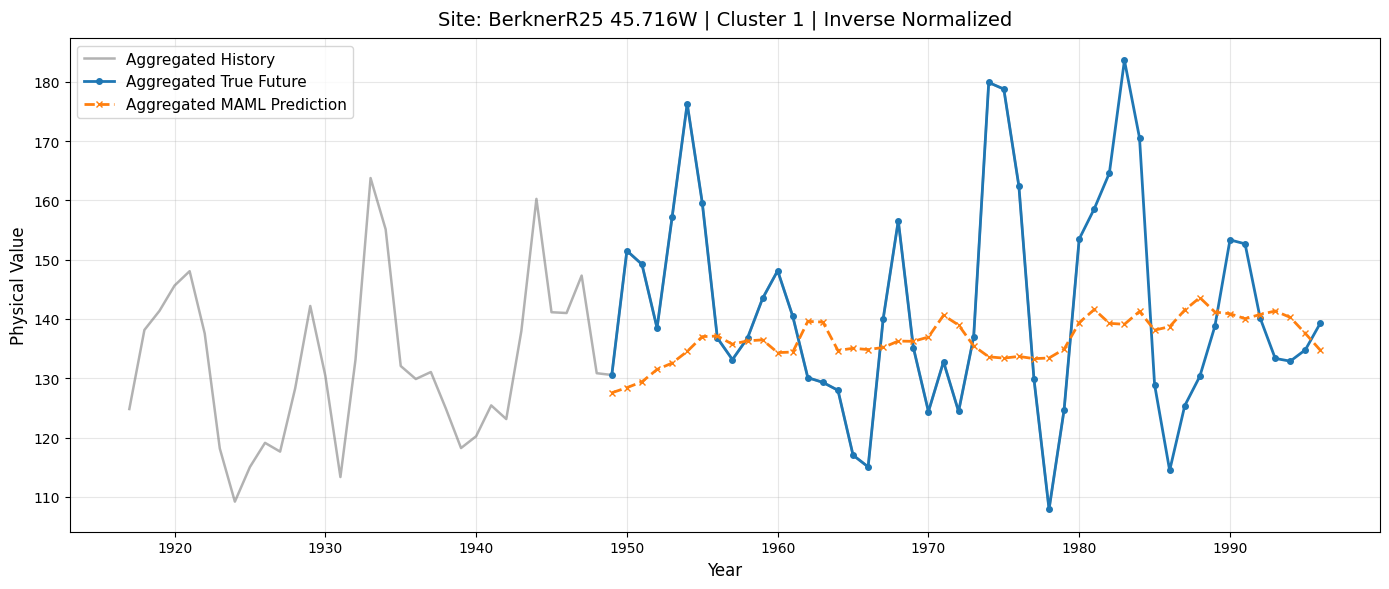

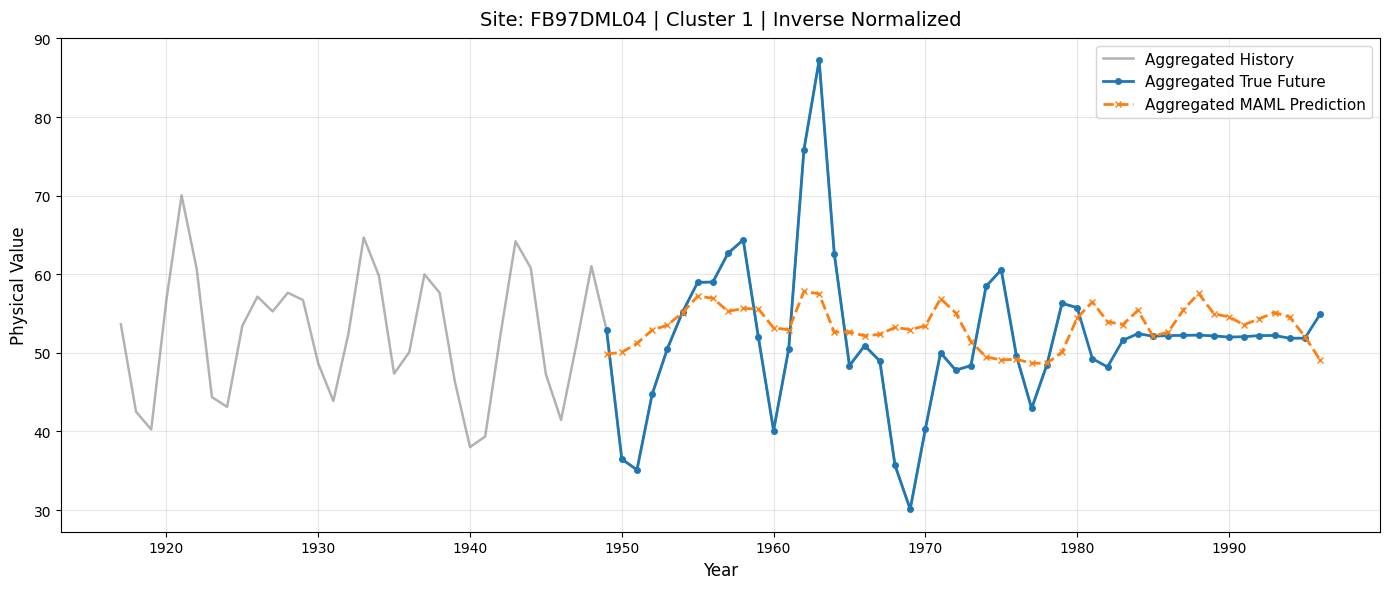

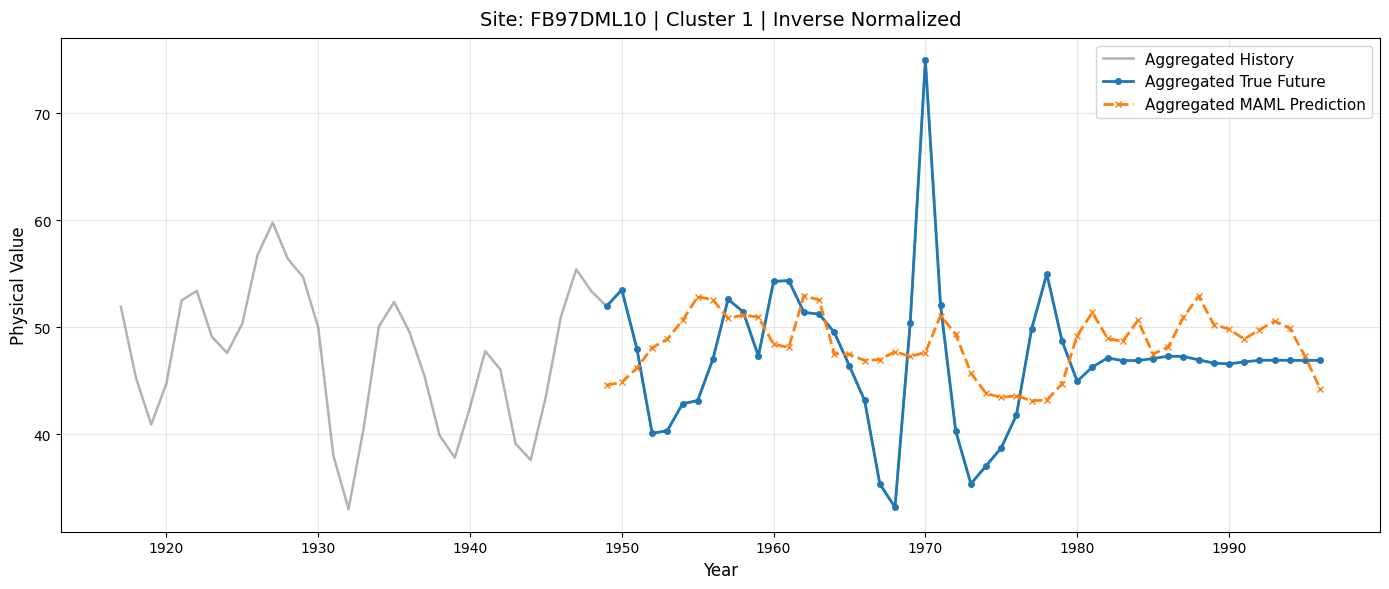

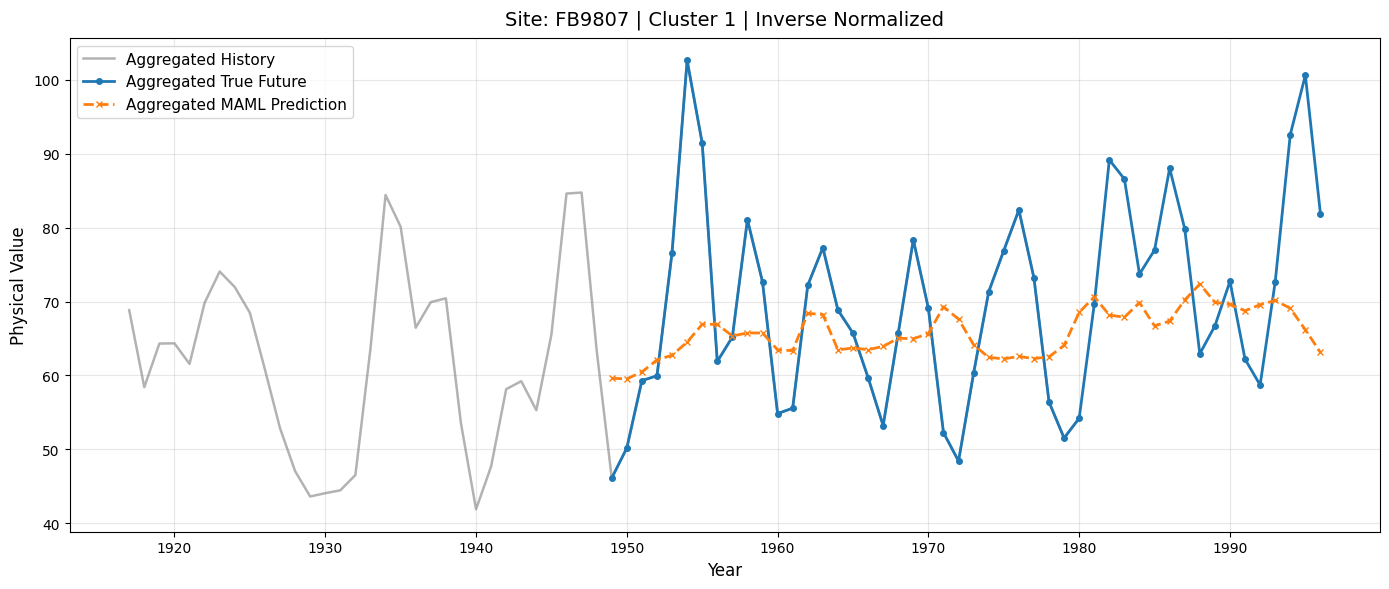

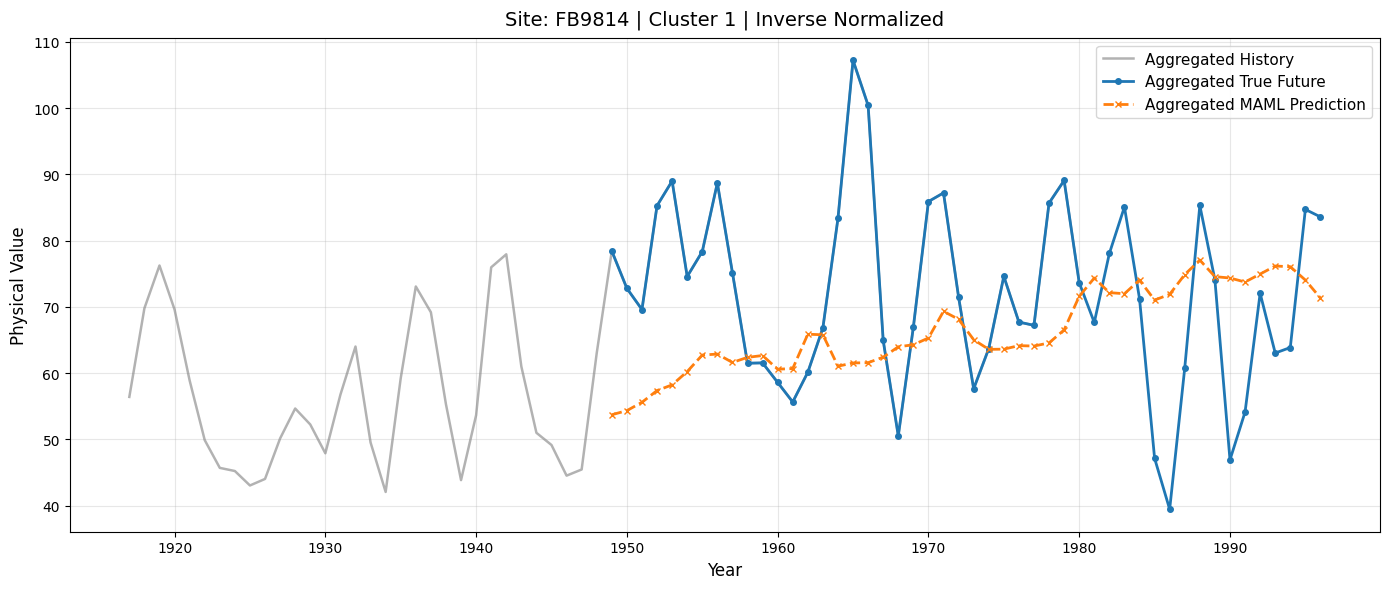

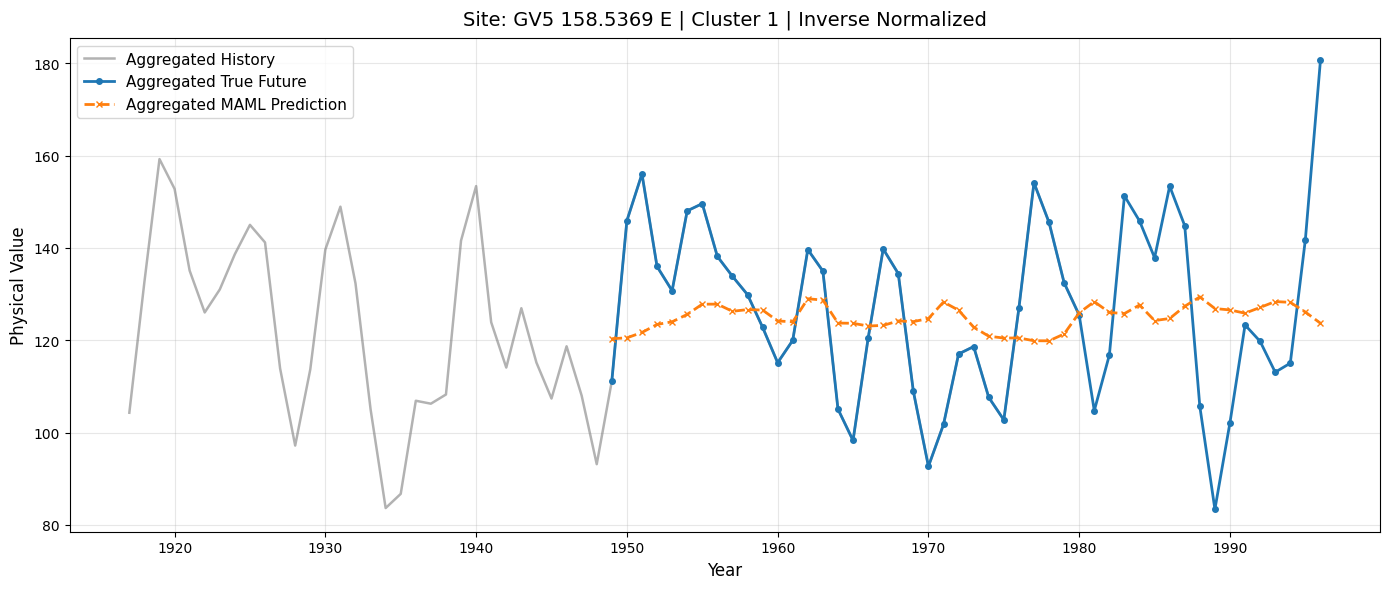

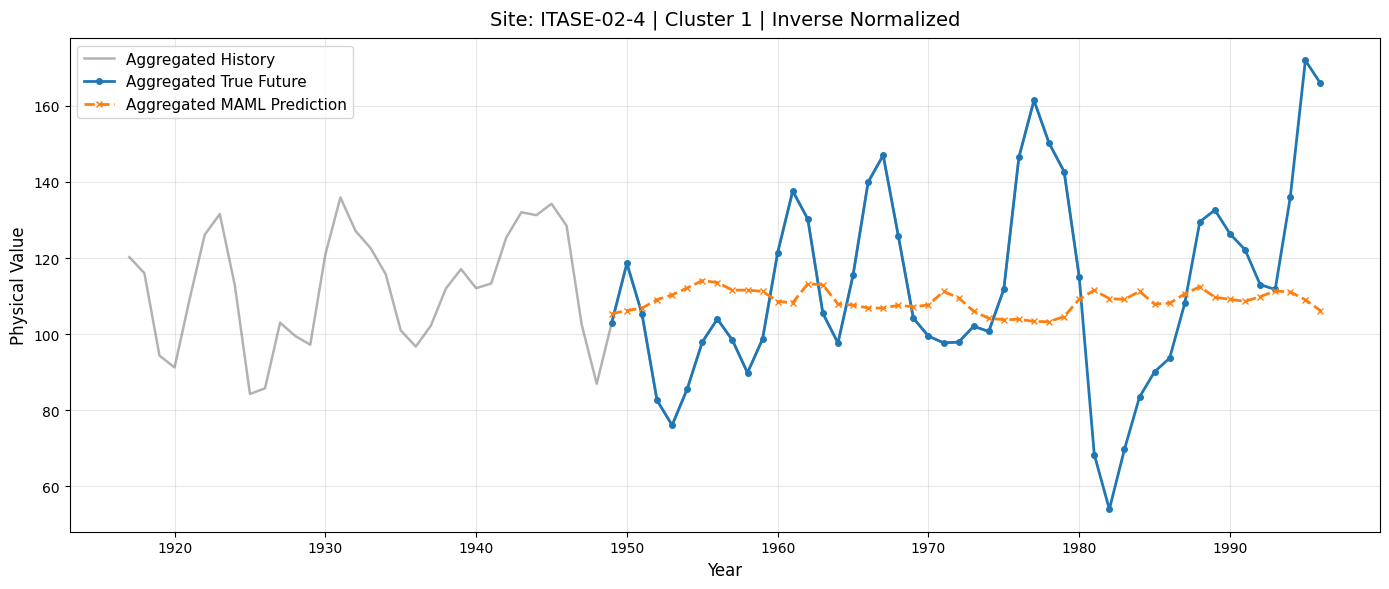

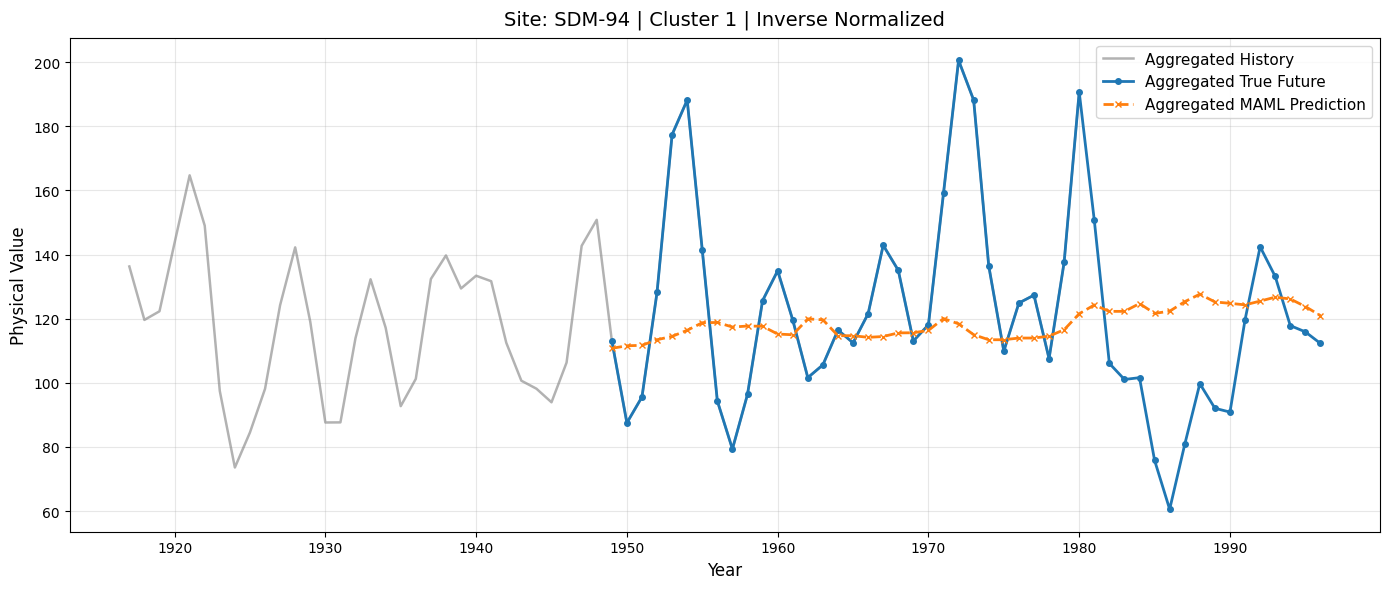

In [6]:
# accum
visualise_icecore_s_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_s_ftS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    root_path=str(PROJECT_ROOT / "dataset/icecore/accum"),
    data_path="accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    save_dir=None,
    show=True,
)

Scaled MSE:   0.051670
Scaled MAE:   0.144894
Physical MSE: 1611.429443
Physical MAE: 25.588001
Cluster 0: Samples=132  | Physical MSE=3058.431396 | Physical MAE=39.804211
Cluster 1: Samples=264  | Physical MSE=288.608490 | Physical MAE=11.560992
Cluster 2: Samples=66   | Physical MSE=4008.708252 | Physical MAE=53.263611
Site FB96DML01 pre-aggregation window scaled metrics | mse=0.0010, mae=0.0260, corr=-0.1498, corr_smooth_3=-0.2377, a3_corr=-0.2527, trend_corr=-0.0124, direction_acc=50.3%, lag_corr@±2=0.2427, best_lag=2, PeakRecall@10%_±2=0.1970, PeakPrecision@10%_±2=0.1970, PeakF1@10%_±2=0.1970
Site FB96DML01 post-aggregation curve scaled metrics | mse=0.0009, mae=0.0243, corr=-0.1313, corr_smooth_3=-0.2325, a3_corr=-0.4176, trend_corr=0.0089, direction_acc=46.8%, lag_corr@±2=0.0601, best_lag=2, PeakRecall@10%_±2=0.0000, PeakPrecision@10%_±2=0.0000, PeakF1@10%_±2=0.0000


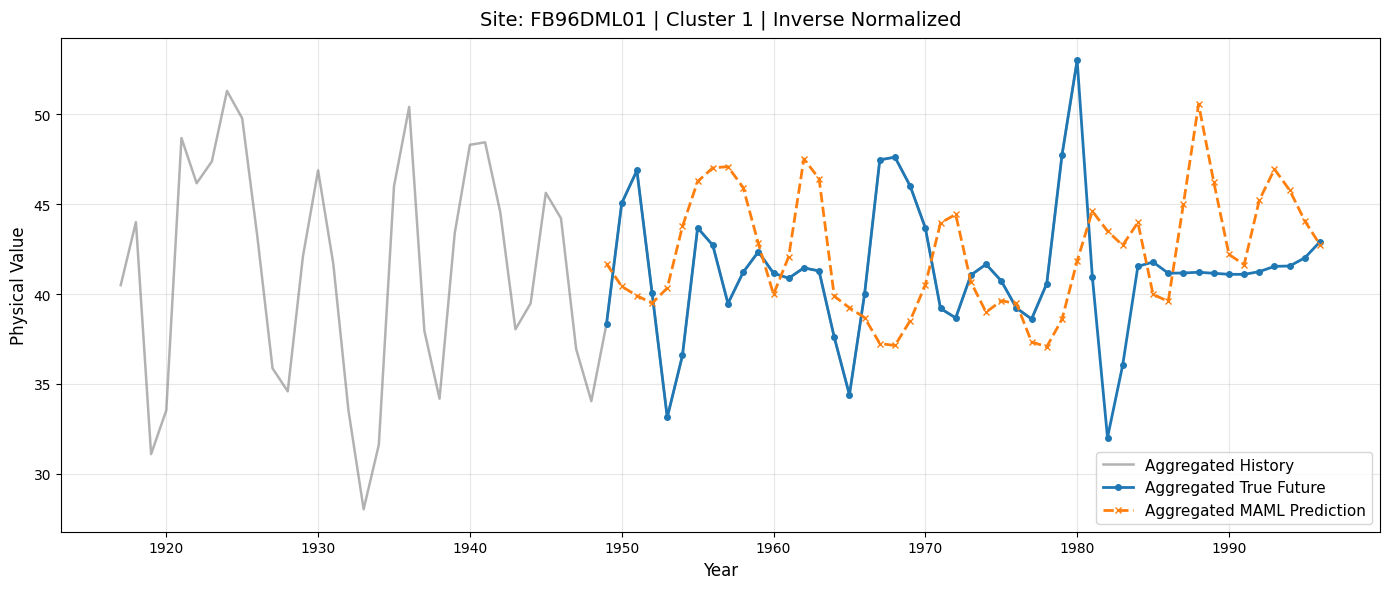

Site FB97DML06 pre-aggregation window scaled metrics | mse=0.0057, mae=0.0547, corr=0.1460, corr_smooth_3=0.2660, a3_corr=0.5430, trend_corr=-0.0696, direction_acc=54.7%, lag_corr@±2=0.4247, best_lag=-2, PeakRecall@10%_±2=0.3788, PeakPrecision@10%_±2=0.3788, PeakF1@10%_±2=0.3788
Site FB97DML06 post-aggregation curve scaled metrics | mse=0.0049, mae=0.0494, corr=0.0072, corr_smooth_3=0.0982, a3_corr=0.0280, trend_corr=-0.1985, direction_acc=51.1%, lag_corr@±2=0.2703, best_lag=-2, PeakRecall@10%_±2=0.4000, PeakPrecision@10%_±2=0.4000, PeakF1@10%_±2=0.4000


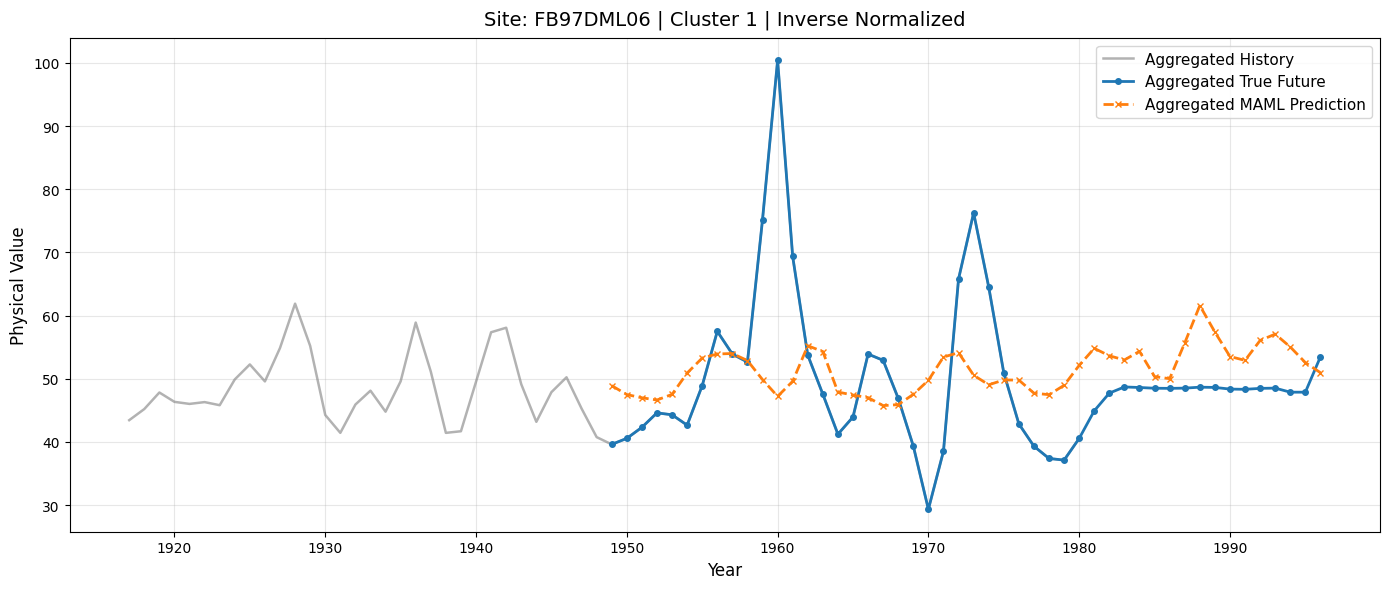

Site FB97DML09 pre-aggregation window scaled metrics | mse=0.0023, mae=0.0353, corr=-0.1335, corr_smooth_3=-0.1586, a3_corr=-0.2695, trend_corr=-0.0595, direction_acc=45.7%, lag_corr@±2=0.2514, best_lag=2, PeakRecall@10%_±2=0.3636, PeakPrecision@10%_±2=0.3636, PeakF1@10%_±2=0.3636
Site FB97DML09 post-aggregation curve scaled metrics | mse=0.0026, mae=0.0374, corr=-0.2864, corr_smooth_3=-0.3918, a3_corr=-0.6918, trend_corr=-0.0580, direction_acc=42.6%, lag_corr@±2=-0.0360, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


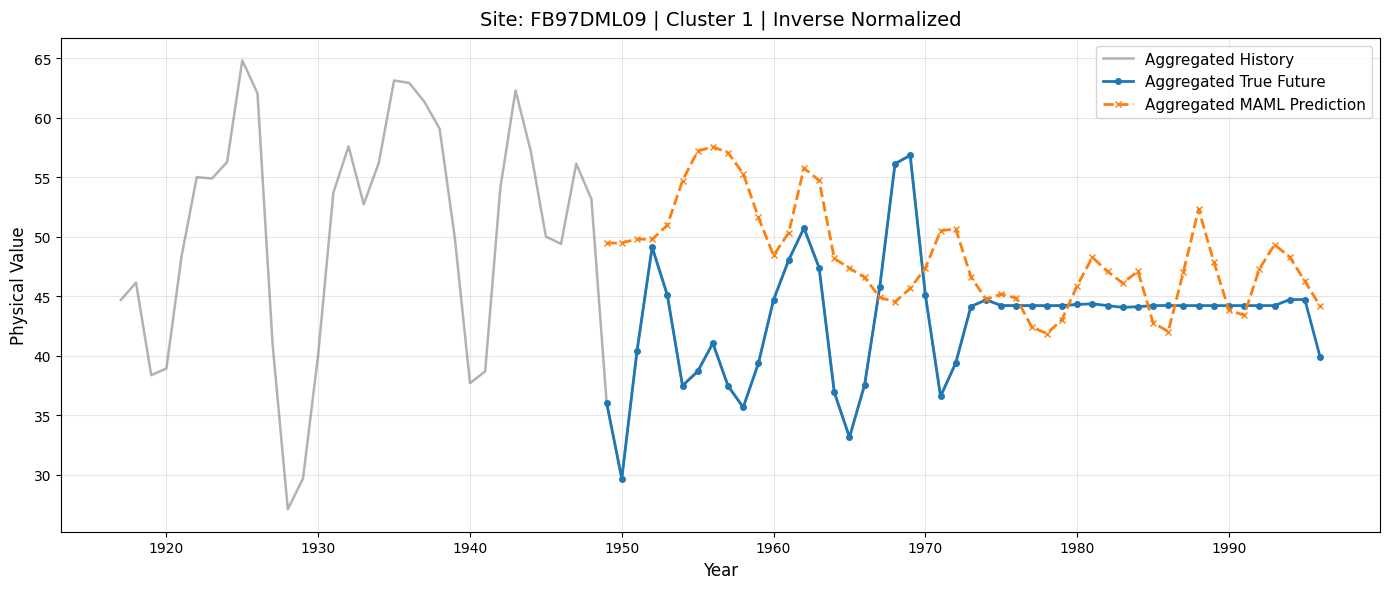

Site FB97DML10 pre-aggregation window scaled metrics | mse=0.0020, mae=0.0327, corr=0.0728, corr_smooth_3=0.1416, a3_corr=0.1549, trend_corr=-0.0667, direction_acc=56.2%, lag_corr@±2=0.2791, best_lag=2, PeakRecall@10%_±2=0.2727, PeakPrecision@10%_±2=0.2727, PeakF1@10%_±2=0.2727
Site FB97DML10 post-aggregation curve scaled metrics | mse=0.0016, mae=0.0313, corr=0.1277, corr_smooth_3=0.2014, a3_corr=0.4199, trend_corr=-0.0208, direction_acc=57.4%, lag_corr@±2=0.2286, best_lag=1, PeakRecall@10%_±2=0.0000, PeakPrecision@10%_±2=0.0000, PeakF1@10%_±2=0.0000


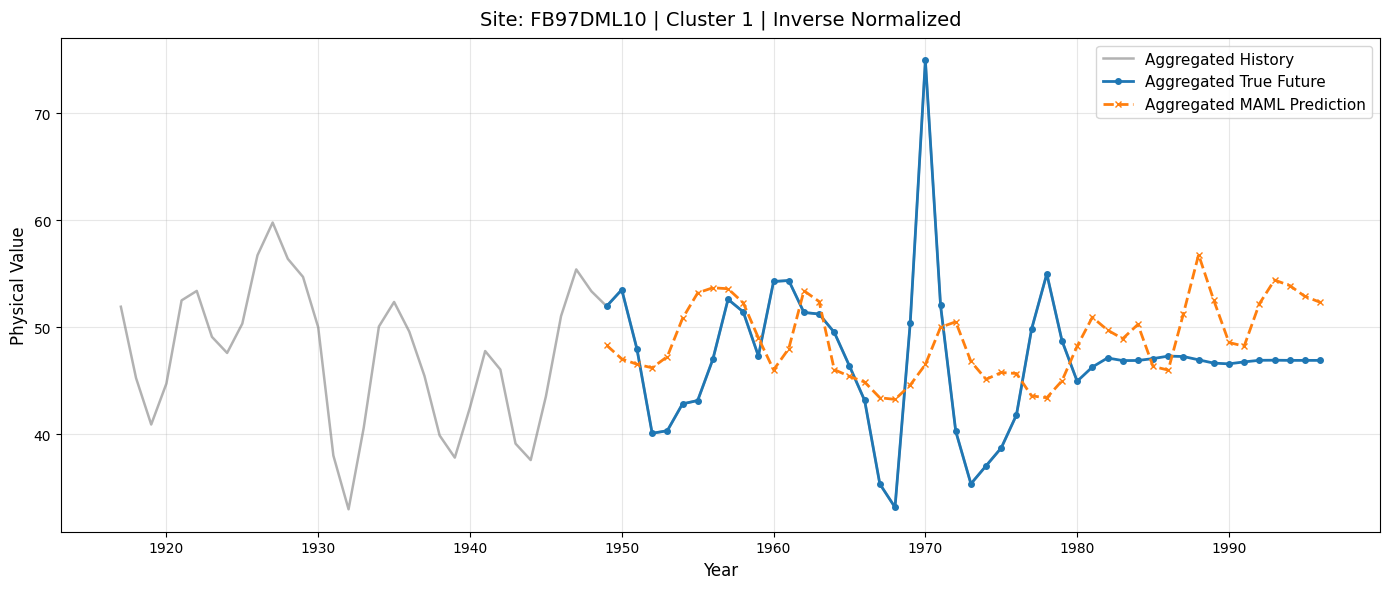

Site FB9802 pre-aggregation window scaled metrics | mse=0.0135, mae=0.0945, corr=0.0344, corr_smooth_3=-0.0862, a3_corr=0.0627, trend_corr=0.3788, direction_acc=56.8%, lag_corr@±2=0.0344, best_lag=0, PeakRecall@10%_±2=0.6515, PeakPrecision@10%_±2=0.6515, PeakF1@10%_±2=0.6515
Site FB9802 post-aggregation curve scaled metrics | mse=0.0149, mae=0.0993, corr=-0.1837, corr_smooth_3=-0.3121, a3_corr=-0.4673, trend_corr=0.4054, direction_acc=53.2%, lag_corr@±2=-0.1837, best_lag=0, PeakRecall@10%_±2=0.4000, PeakPrecision@10%_±2=0.4000, PeakF1@10%_±2=0.4000


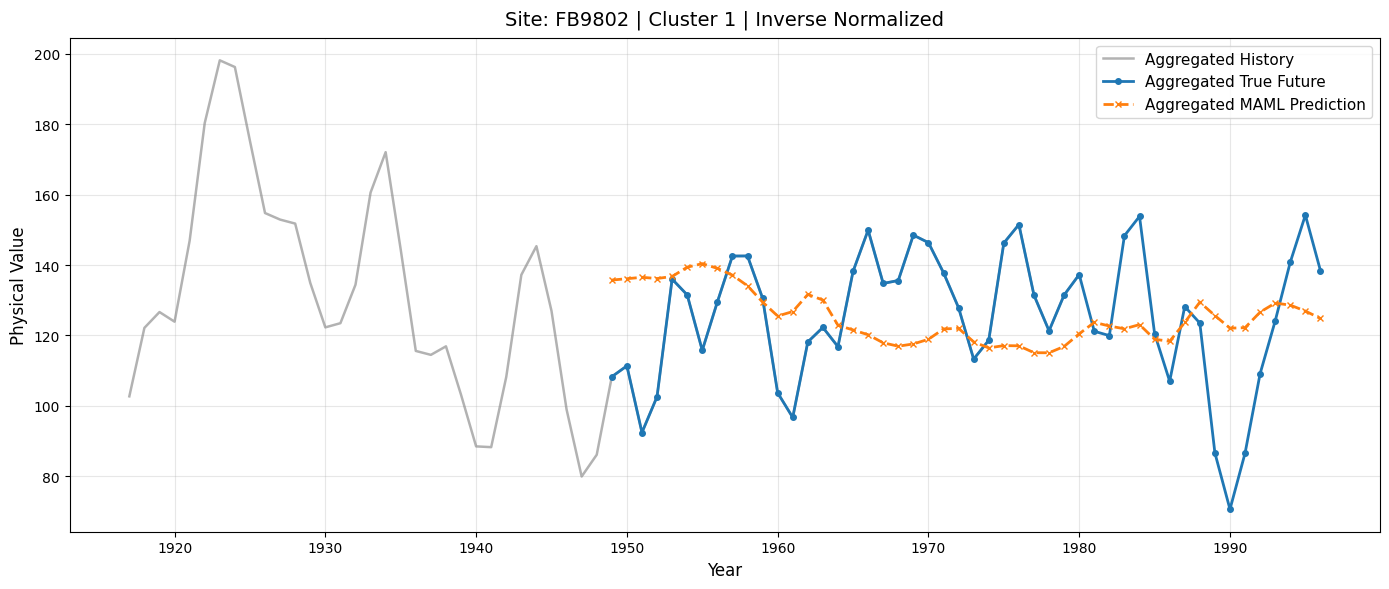

Site FB9813 pre-aggregation window scaled metrics | mse=0.0013, mae=0.0291, corr=-0.1401, corr_smooth_3=-0.2179, a3_corr=-0.1966, trend_corr=-0.0373, direction_acc=44.2%, lag_corr@±2=-0.0278, best_lag=-2, PeakRecall@10%_±2=0.2727, PeakPrecision@10%_±2=0.2727, PeakF1@10%_±2=0.2727
Site FB9813 post-aggregation curve scaled metrics | mse=0.0017, mae=0.0325, corr=-0.3530, corr_smooth_3=-0.5037, a3_corr=-0.6462, trend_corr=0.0841, direction_acc=44.7%, lag_corr@±2=-0.1704, best_lag=-2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


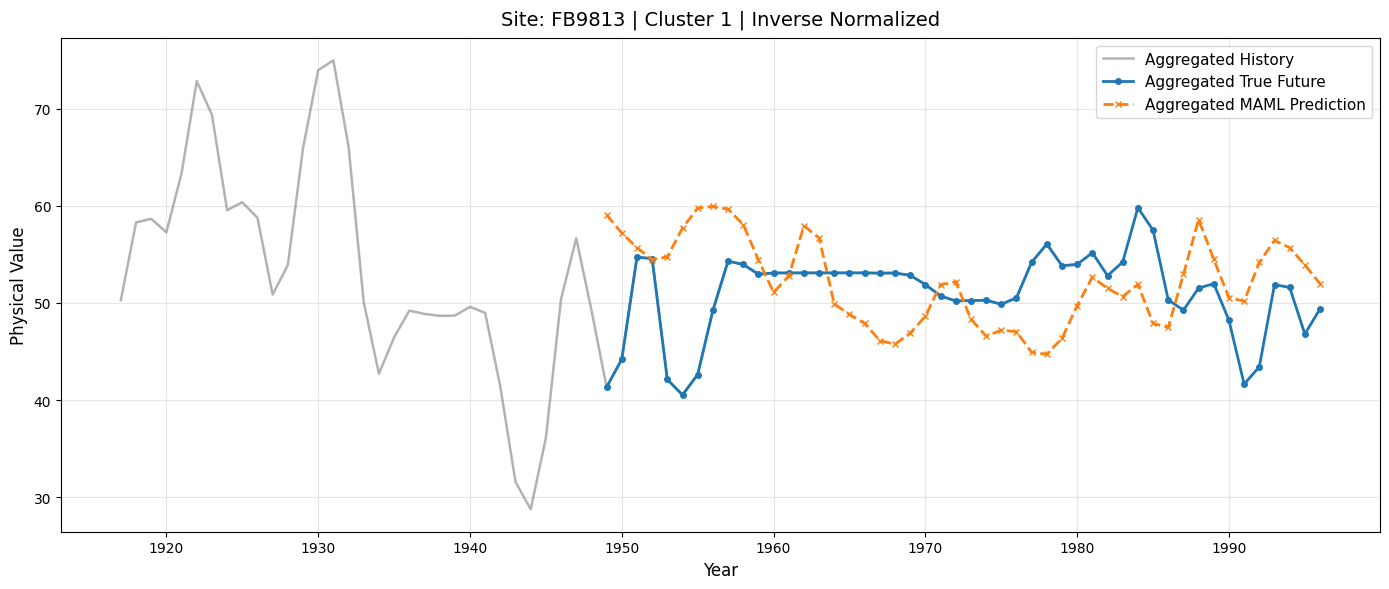

Site Hercules Neve 165.4 E pre-aggregation window scaled metrics | mse=0.0240, mae=0.1264, corr=0.0021, corr_smooth_3=0.0461, a3_corr=0.0249, trend_corr=-0.0641, direction_acc=52.7%, lag_corr@±2=0.1202, best_lag=2, PeakRecall@10%_±2=0.5455, PeakPrecision@10%_±2=0.5455, PeakF1@10%_±2=0.5455
Site Hercules Neve 165.4 E post-aggregation curve scaled metrics | mse=0.0251, mae=0.1345, corr=-0.2802, corr_smooth_3=-0.3266, a3_corr=-0.5599, trend_corr=-0.1859, direction_acc=48.9%, lag_corr@±2=-0.0574, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


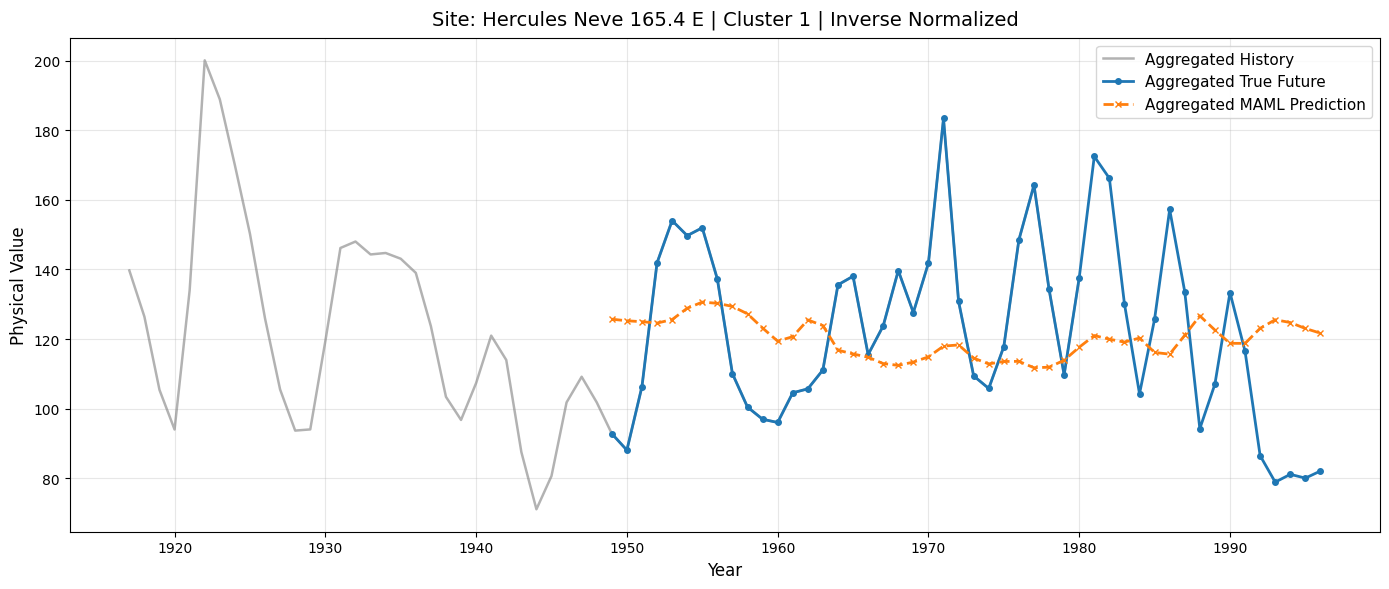

Site ITASE-02-4 pre-aggregation window scaled metrics | mse=0.0243, mae=0.1249, corr=-0.2835, corr_smooth_3=-0.3307, a3_corr=-0.3041, trend_corr=-0.1090, direction_acc=43.0%, lag_corr@±2=-0.1532, best_lag=2, PeakRecall@10%_±2=0.3788, PeakPrecision@10%_±2=0.3788, PeakF1@10%_±2=0.3788
Site ITASE-02-4 post-aggregation curve scaled metrics | mse=0.0257, mae=0.1267, corr=-0.4989, corr_smooth_3=-0.5814, a3_corr=-0.5319, trend_corr=-0.1333, direction_acc=46.8%, lag_corr@±2=-0.3315, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


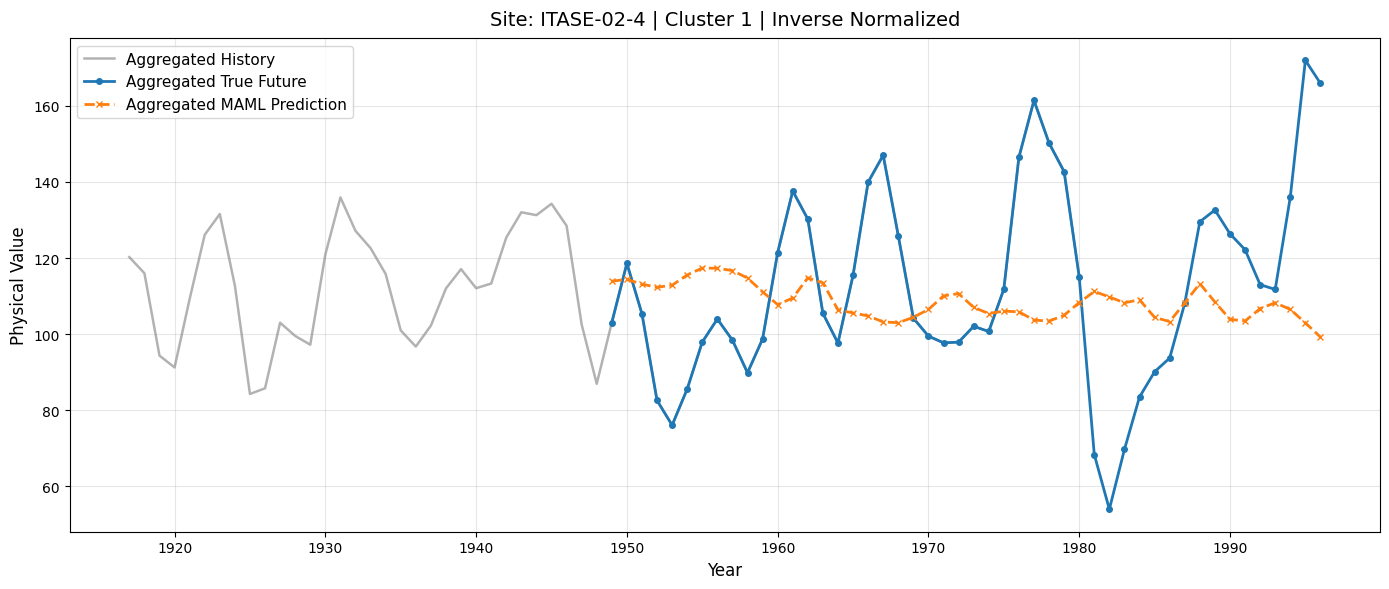

In [14]:
# accum
visualise_icecore_s_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_s_protoprototypes/accum_s_encoder_proto_k6.npz_ftS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    root_path=str(PROJECT_ROOT / "dataset/icecore/accum"),
    data_path="accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    save_dir=None,
    show=True,
)

## CrossVar_pred

- crossvar / average / inverse_transform

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from data_provider.icecore_data_loader import Dataset_IceCore_CrossVar
from utils.metrics import (
    metric,
    pearson_corr,
    trend_corr,
    direction_accuracy,
    lag_aware_corr,
    smooth_corr,
    a3_corr,
    peak_event_metrics,
)
print("PROJECT_ROOT =", PROJECT_ROOT)

import numpy as np


def _to_str_array(arr):
    """
    把 npz 里保存的 sites 转成一维字符串数组。
    兼容 bytes / object / str。
    """
    arr = np.asarray(arr).reshape(-1)

    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out)




def _calc_prediction_metrics(pred_values, true_values):
    # 和 test() 使用同一套指标，输入保持为反归一化之前的值。
    # pred_values / true_values: [N, T] 或 [N, T, C]
    pred_values = np.asarray(pred_values)
    true_values = np.asarray(true_values)

    mae, mse, rmse, mape, mspe = metric(pred_values, true_values)
    corr = pearson_corr(pred_values, true_values)
    trend_corr_value = trend_corr(pred_values, true_values)
    direction_acc = direction_accuracy(pred_values, true_values)
    lag_corr, best_lag = lag_aware_corr(pred_values, true_values, max_lag=2)
    corr_smooth_3 = smooth_corr(pred_values, true_values, window=3)
    a3_corr_value = a3_corr(pred_values, true_values)
    peak_recall, peak_precision, peak_f1 = peak_event_metrics(
        pred_values,
        true_values,
        top_ratio=0.1,
        lag_window=2,
    )

    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "mspe": mspe,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "a3_corr": a3_corr_value,
        "trend_corr": trend_corr_value,
        "direction_acc": direction_acc,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "peak_recall_10_lag2": peak_recall,
        "peak_precision_10_lag2": peak_precision,
        "peak_f1_10_lag2": peak_f1,
    }


def _print_site_prediction_metrics(site_name, metrics, stage="metrics"):
    # 打印单个被绘制站点的指标，数值来自反归一化之前的 preds/trues。
    print(
        f"Site {site_name} {stage} | "
        f"mse={metrics['mse']:.4f}, mae={metrics['mae']:.4f}, "
        f"corr={metrics['corr']:.4f}, "
        f"corr_smooth_3={metrics['corr_smooth_3']:.4f}, "
        f"a3_corr={metrics['a3_corr']:.4f}, "
        f"trend_corr={metrics['trend_corr']:.4f}, "
        f"direction_acc={metrics['direction_acc'] * 100:.1f}%, "
        f"lag_corr@±2={metrics['lag_corr']:.4f}, "
        f"best_lag={metrics['best_lag']}, "
        f"PeakRecall@10%_±2={metrics['peak_recall_10_lag2']:.4f}, "
        f"PeakPrecision@10%_±2={metrics['peak_precision_10_lag2']:.4f}, "
        f"PeakF1@10%_±2={metrics['peak_f1_10_lag2']:.4f}"
    )

def _calc_mean_and_sort(agg_dict):
    """
    对 {year: [v1, v2, ...]} 按年份排序，并对同一年份的多个值取平均。

    Return:
        years: list[int]
        vals:  np.ndarray, shape [T]
    """
    if len(agg_dict) == 0:
        return [], np.array([])

    years = sorted(agg_dict.keys())
    vals = np.array(
        [np.nanmean(agg_dict[yr]) for yr in years],
        dtype=float
    )

    return years, vals


def _safe_inverse_transform_crossvar(dataset, values, var="y"):
    """
    CrossVar 可视化专用反归一化函数。

    参数:
        dataset: Dataset_IceCore_CrossVar 实例
        values: 一维数组/list，通常是聚合后的 input / true / pred
        var: "x" 或 "y"

    逻辑:
        1. 优先调用新版 dataset.inverse_transform(values, var="x"/"y")
        2. 如果旧版 Dataset 不支持 var 参数，则尝试 x_scaler / y_scaler
        3. 如果都失败，则返回原值，避免画图直接崩掉
    """
    values = np.asarray(values, dtype=float)

    if values.size == 0:
        return values

    original_shape = values.shape
    values_2d = values.reshape(-1, 1)

    # ---------------------------------------------------------
    # 1. 优先使用 Dataset 自带 inverse_transform
    # ---------------------------------------------------------
    if hasattr(dataset, "inverse_transform"):
        try:
            inv = dataset.inverse_transform(values_2d, var=var)
            return np.asarray(inv).reshape(original_shape)
        except TypeError:
            # 兼容旧版本：inverse_transform 不接受 var 参数
            try:
                inv = dataset.inverse_transform(values_2d)
                return np.asarray(inv).reshape(original_shape)
            except Exception:
                pass
        except Exception:
            pass

    # ---------------------------------------------------------
    # 2. 如果 Dataset 有 x_scaler / y_scaler，则手动反归一化
    # ---------------------------------------------------------
    scaler_attr_candidates = []

    if var == "x":
        scaler_attr_candidates = [
            "x_scaler",
            "scaler_x",
            "scaler",
        ]
    elif var == "y":
        scaler_attr_candidates = [
            "y_scaler",
            "scaler_y",
            "scaler",
        ]
    else:
        raise ValueError("var must be either 'x' or 'y'.")

    for attr in scaler_attr_candidates:
        if hasattr(dataset, attr):
            scaler = getattr(dataset, attr)

            if scaler is None:
                continue

            try:
                inv = scaler.inverse_transform(values_2d)
                return np.asarray(inv).reshape(original_shape)
            except Exception:
                continue

    # ---------------------------------------------------------
    # 3. 最后兜底：返回原值，避免画图中断
    # ---------------------------------------------------------
    print(
        f"⚠️ Warning: inverse_transform failed for var='{var}'. "
        "Return scaled values instead."
    )
    return values.reshape(original_shape)

def visualise_icecore_crossvar_with_history(
    npz_path,
    target_cluster,
    root_path,
    x_data_path,
    y_data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    x_label="Input variable",
    y_label="Target variable",
    show=True,
):
    """
    适配新版 Dataset_IceCore_CrossVar 的可视化函数。

    功能：
    1. 读取 results.npz 中的 preds / trues / inputs / sites / years / clusters
    2. 对同一站点、同一年份的多个预测样本求平均
    3. 输入变量 x 用 x_scaler 反归一化
    4. 目标变量 y 的 true / pred 用 y_scaler 反归一化
    5. 一张图上下两个子图：
       - 上图：输入变量 x
       - 下图：目标变量 y 的真实值和预测值
    6. 上下图年份对齐，共享 x 轴
    """

    # =========================================================
    # 1. 构造 Dataset_IceCore_CrossVar，用它的 x/y scaler 做 inverse_transform
    # =========================================================
    dataset = Dataset_IceCore_CrossVar(
        root_path=root_path,
        data_path=None,
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="S",
        target="na",
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    # =========================================================
    # 2. 读取 npz
    # =========================================================
    data = np.load(npz_path, allow_pickle=True)

    preds = data["preds"]       # expected: [N, seq_len, C] for CrossVar
    trues = data["trues"]       # expected: [N, seq_len, C] for CrossVar
    sites = _to_str_array(data["sites"])
    years = data["years"]
    clusters = np.asarray(data["clusters"]).reshape(-1)

    has_inputs = "inputs" in data
    inputs = data["inputs"] if has_inputs else None

    # =========================================================
    # 3. 打印 scaled 指标和反归一化后的目标变量指标
    # =========================================================
    scaled_mse = np.mean((preds - trues) ** 2)
    scaled_mae = np.mean(np.abs(preds - trues))

    preds_flat = preds[:, :, -1].reshape(-1, 1)
    trues_flat = trues[:, :, -1].reshape(-1, 1)

    preds_inv = dataset.inverse_transform(preds_flat, var="y")
    trues_inv = dataset.inverse_transform(trues_flat, var="y")

    physical_mse = np.mean((preds_inv - trues_inv) ** 2)
    physical_mae = np.mean(np.abs(preds_inv - trues_inv))

    print("=" * 60)
    print(f"CrossVar: {x_data_path} -> {y_data_path}")
    print(f"Scaled MSE:   {scaled_mse:.6f}")
    print(f"Scaled MAE:   {scaled_mae:.6f}")
    print(f"Physical MSE: {physical_mse:.6f}")
    print(f"Physical MAE: {physical_mae:.6f}")
    print("=" * 60)

    for cid in sorted(np.unique(clusters)):
        mask = clusters == cid
        if not np.any(mask):
            continue

        c_preds = preds[mask, :, -1].reshape(-1, 1)
        c_trues = trues[mask, :, -1].reshape(-1, 1)

        c_preds_inv = dataset.inverse_transform(c_preds, var="y")
        c_trues_inv = dataset.inverse_transform(c_trues, var="y")

        c_mse = np.mean((c_preds_inv - c_trues_inv) ** 2)
        c_mae = np.mean(np.abs(c_preds_inv - c_trues_inv))

        print(
            f"Cluster {cid}: "
            f"Samples={np.sum(mask):<4} | "
            f"Physical MSE={c_mse:.6f} | "
            f"Physical MAE={c_mae:.6f}"
        )

    print("=" * 60)

    # =========================================================
    # 4. 筛选目标 cluster
    # =========================================================
    target_indices = np.where(clusters == target_cluster)[0]

    if len(target_indices) == 0:
        print(f"❌ 未找到 Cluster {target_cluster} 的数据。")
        return

    unique_sites = np.unique(sites[target_indices])

    # =========================================================
    # 5. 按站点聚合：同一年份多个样本求平均
    # =========================================================
    for site_name in unique_sites:
        site_mask = (sites == site_name) & (clusters == target_cluster)
        site_idx_list = np.where(site_mask)[0]

        agg_inputs = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        site_metrics = _calc_prediction_metrics(
            preds[site_idx_list, :, -1],
            trues[site_idx_list, :, -1],
        )
        _print_site_prediction_metrics(
            site_name,
            site_metrics,
            stage="pre-aggregation window scaled metrics",
        )


        for idx in site_idx_list:
            # -------------------------------------------------
            # 5.1 解析年份
            # -------------------------------------------------
            year_item = years[idx]
            year_arr = np.asarray(year_item).reshape(-1)

            # CrossVar 可能保存：
            # A. 完整年份序列: [year_1, year_2, ..., year_seq_len]
            # B. 起始年份 scalar: year_start
            if len(year_arr) > 1:
                cur_years = year_arr.astype(int)
            else:
                start_year = int(year_arr[0])
                cur_years = np.arange(start_year, start_year + trues.shape[1])

            # -------------------------------------------------
            # 5.2 聚合输入变量 x
            # -------------------------------------------------
            if has_inputs:
                input_seq = inputs[idx, :, -1]
                usable_input_len = min(len(cur_years), len(input_seq))

                for j in range(usable_input_len):
                    yr = int(cur_years[j])
                    agg_inputs[yr].append(float(input_seq[j]))

            # -------------------------------------------------
            # 5.3 聚合目标变量 y 的真值和预测值
            # -------------------------------------------------
            y_true_seq = trues[idx, :, -1]
            y_pred_seq = preds[idx, :, -1]

            usable_len = min(len(cur_years), len(y_true_seq), len(y_pred_seq))

            for j in range(usable_len):
                yr = int(cur_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        # =====================================================
        # 6. 同一年份样本求平均
        # =====================================================
        input_years, input_vals = _calc_mean_and_sort(agg_inputs)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        post_agg_metrics = _calc_prediction_metrics(
            np.asarray(pred_vals, dtype=np.float32)[None, :],
            np.asarray(true_vals, dtype=np.float32)[None, :],
        )
        _print_site_prediction_metrics(
            site_name,
            post_agg_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        # =====================================================
        # 7. 反归一化
        # =====================================================
        input_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            input_vals,
            var="x"
        )

        true_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            true_vals,
            var="y"
        )

        pred_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            pred_vals,
            var="y"
        )

        # =====================================================
        # 8. 年份对齐：统一 x 轴范围和 ticks
        # =====================================================
        all_years = sorted(
            set(input_years)
            | set(true_years)
            | set(pred_years)
        )

        if len(all_years) == 0:
            print(f"⚠️ Site {site_name} 没有可画的年份数据。")
            continue

        x_min, x_max = min(all_years), max(all_years)

        # 年份太密时少显示一些 tick，避免堆在一起
        if len(all_years) > 20:
            step = max(1, len(all_years) // 10)
            tick_years = all_years[::step]
            if all_years[-1] not in tick_years:
                tick_years.append(all_years[-1])
        else:
            tick_years = all_years

        # =====================================================
        # 9. 一张图，上下两个子图
        # =====================================================
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(14, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [1, 1.25]}
        )

        ax_input = axes[0]
        ax_target = axes[1]

        # -------------------------
        # 上图：输入变量 x
        # -------------------------
        if has_inputs and len(input_years) > 0:
            ax_input.plot(
                input_years,
                input_vals_inv,
                label=f"{x_label} input",
                color="gray",
                linestyle="-",
                marker=".",
                markersize=4,
                alpha=0.8,
                linewidth=1.8,
            )
        else:
            ax_input.text(
                0.5,
                0.5,
                "No input sequence found in npz",
                ha="center",
                va="center",
                transform=ax_input.transAxes,
                fontsize=11,
            )

        ax_input.set_xlim(x_min, x_max)
        ax_input.set_ylabel(x_label, fontsize=11)
        ax_input.set_title(
            f"Site: {site_name} | Cluster {target_cluster} | CrossVar: {x_label} → {y_label}",
            fontsize=14,
            pad=10,
        )
        ax_input.legend(loc="best", fontsize=10)
        ax_input.grid(True, alpha=0.3)

        # -------------------------
        # 下图：目标变量 y true / pred
        # -------------------------
        ax_target.plot(
            true_years,
            true_vals_inv,
            label=f"True {y_label}",
            color="#1f77b4",
            marker="o",
            markersize=4,
            linewidth=2,
        )

        ax_target.plot(
            pred_years,
            pred_vals_inv,
            label=f"Predicted {y_label}",
            color="#ff7f0e",
            linestyle="--",
            marker="x",
            markersize=5,
            linewidth=2,
        )

        ax_target.set_xlim(x_min, x_max)
        ax_target.set_xlabel("Year", fontsize=12)
        ax_target.set_ylabel(y_label, fontsize=11)
        ax_target.legend(loc="best", fontsize=10)
        ax_target.grid(True, alpha=0.3)

        ax_target.set_xticks(tick_years)
        ax_target.set_xticklabels(tick_years, rotation=45)

        plt.tight_layout()

        if show:
            plt.show()
        else:
            plt.close()

PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy


CrossVar: d18O/d18O_clean.csv -> accum/accum_100y.csv
Scaled MSE:   0.404853
Scaled MAE:   0.585645
Physical MSE: 19299.238281
Physical MAE: 127.866325
Cluster 0: Samples=3    | Physical MSE=18761.078125 | Physical MAE=123.657684
Cluster 1: Samples=6    | Physical MSE=19430.380859 | Physical MAE=134.122421
Cluster 2: Samples=3    | Physical MSE=19575.111328 | Physical MAE=119.562767
Site ITASE-00-1 pre-aggregation window scaled metrics | mse=0.3936, mae=0.5664, corr=-0.3832, corr_smooth_3=-0.3668, a3_corr=-0.2316, trend_corr=-0.4246, direction_acc=36.6%, lag_corr@±2=0.1056, best_lag=-2, PeakRecall@10%_±2=0.2500, PeakPrecision@10%_±2=0.2500, PeakF1@10%_±2=0.2500
Site ITASE-00-1 post-aggregation curve scaled metrics | mse=0.3801, mae=0.5570, corr=-0.3837, corr_smooth_3=-0.3644, a3_corr=-0.2694, trend_corr=-0.4407, direction_acc=30.3%, lag_corr@±2=0.1057, best_lag=-2, PeakRecall@10%_±2=0.2500, PeakPrecision@10%_±2=0.2500, PeakF1@10%_±2=0.2500


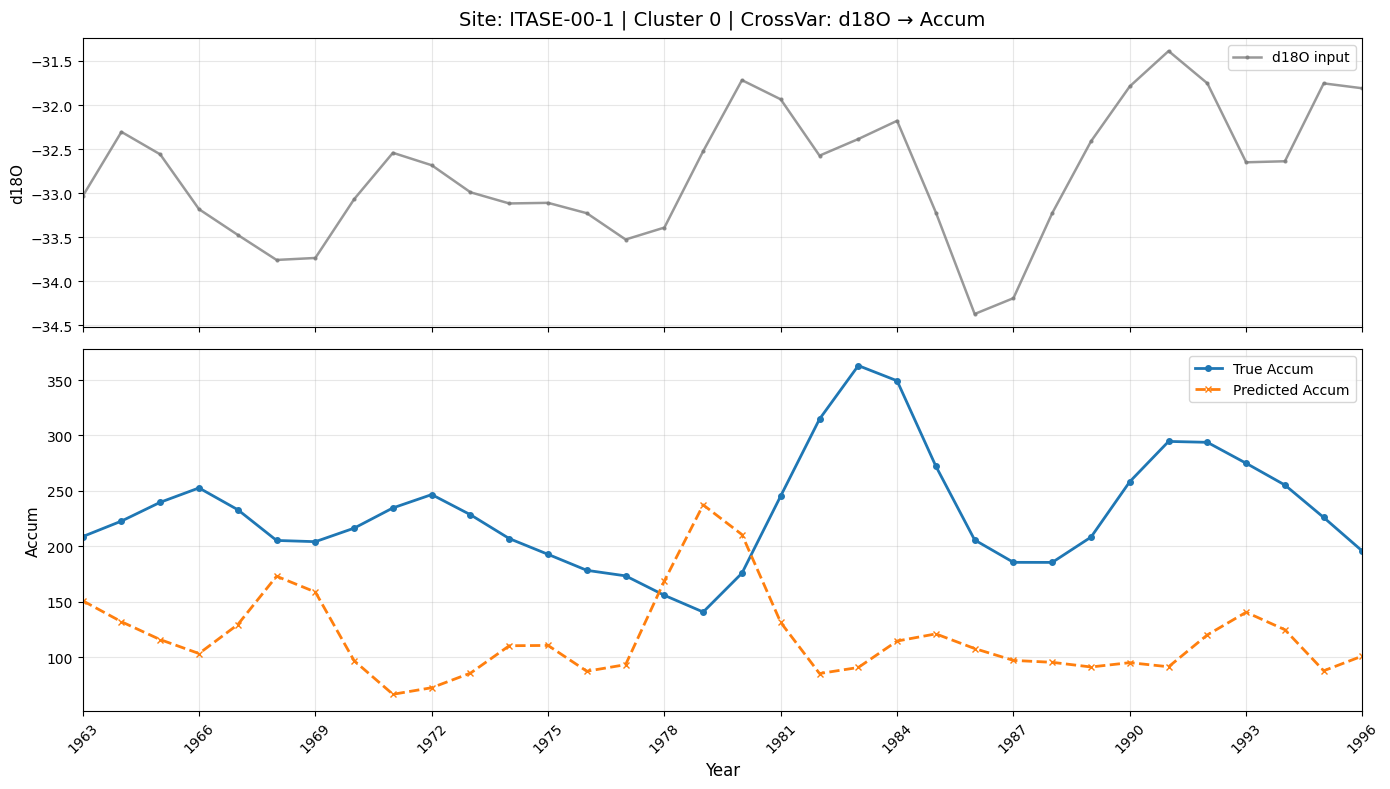

In [19]:
visualise_icecore_crossvar_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=0,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="d18O/d18O_clean.csv",
    y_data_path="accum/accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    x_label="d18O",
    y_label="Accum",
    show=True,
)

CrossVar: d18O/d18O_clean.csv -> accum/accum_100y.csv
Scaled MSE:   0.393532
Scaled MAE:   0.576805
Physical MSE: 18759.611328
Physical MAE: 125.936310
Cluster 0: Samples=3    | Physical MSE=17952.708984 | Physical MAE=121.030403
Cluster 1: Samples=6    | Physical MSE=18582.462891 | Physical MAE=131.091751
Cluster 2: Samples=3    | Physical MSE=19920.806641 | Physical MAE=120.531342
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.4179, mae=0.5520, corr=0.3522, corr_smooth_3=0.4566, a3_corr=0.6600, trend_corr=0.0393, direction_acc=51.6%, lag_corr@±2=0.5088, best_lag=-2, PeakRecall@10%_±2=0.5833, PeakPrecision@10%_±2=0.5833, PeakF1@10%_±2=0.5833
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.4111, mae=0.5495, corr=0.3444, corr_smooth_3=0.4474, a3_corr=0.6749, trend_corr=0.0172, direction_acc=51.5%, lag_corr@±2=0.4928, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


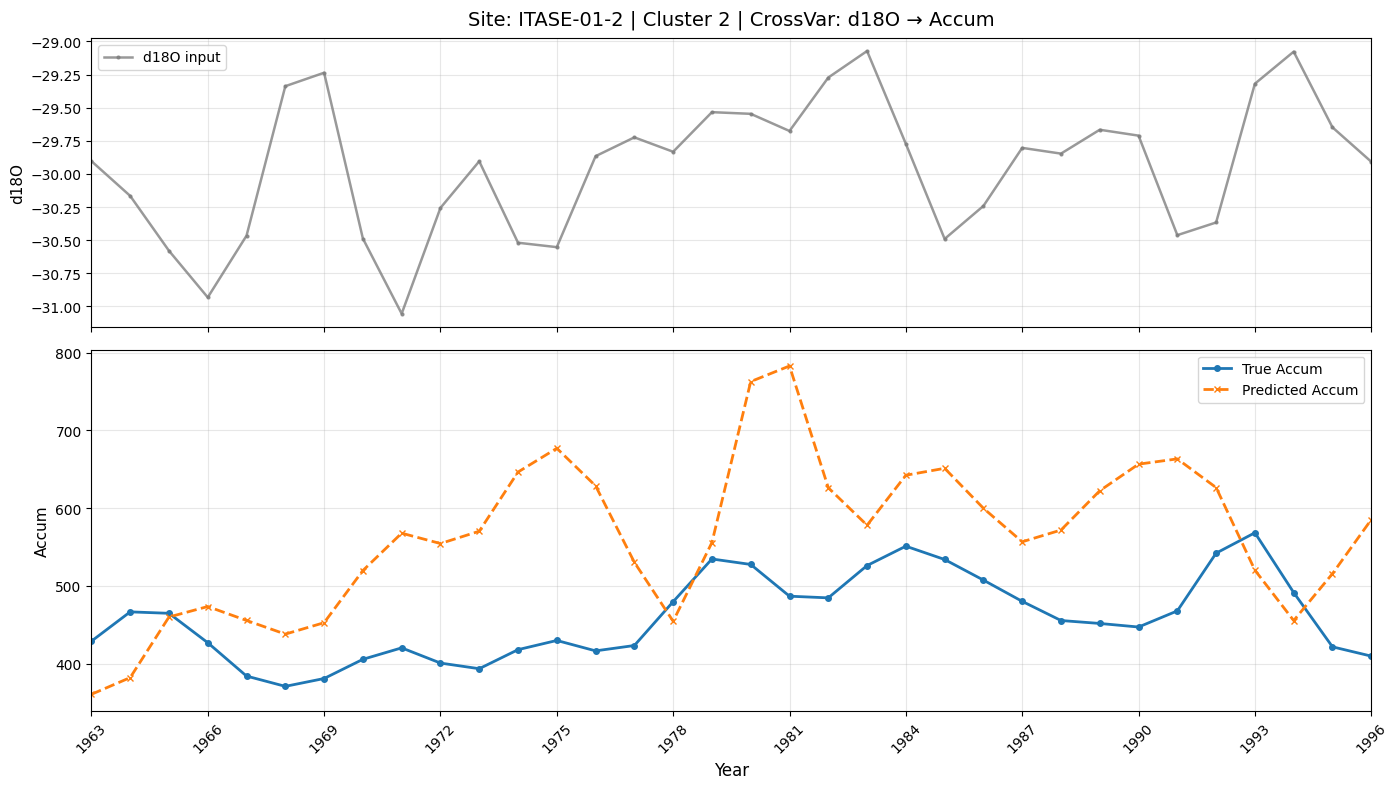

In [22]:
visualise_icecore_crossvar_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_encoder_proto_k6.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="d18O/d18O_clean.csv",
    y_data_path="accum/accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    x_label="d18O",
    y_label="Accum",
    show=True,
)

## CrossVar_full

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def visualise_crossvar_full_series(
    npz_path,
    target_cluster=None,
    site=None,
    max_sites=5,
):
    """
    CrossVar 专用：画完整冰芯序列。

    上图：完整 non-target / x 变量，例如 d18O，灰色真值。
    下图：完整 target / y 变量，灰色真值；query true 蓝色；query pred 橙色。

    需要使用新版 maml_exp 生成的 results.npz，里面包含：
        crossvar_full_sites
        crossvar_full_x
        crossvar_full_y
        crossvar_full_years
        crossvar_full_support_lens
    """
    data = np.load(npz_path, allow_pickle=True)

    required = [
        'preds', 'trues', 'sites', 'years', 'clusters',
        'crossvar_full_sites', 'crossvar_full_x', 'crossvar_full_y',
        'crossvar_full_years', 'crossvar_full_support_lens',
    ]
    missing = [k for k in required if k not in data]
    if missing:
        raise KeyError(
            f"results.npz 缺少 CrossVar 完整序列字段: {missing}。"
            "需要用新版 maml_exp_long_term_forecasting.py 重新跑一次 test。"
        )

    def _squeeze_target_array(arr, name):
        arr = np.asarray(arr)
        if arr.ndim == 3 and arr.shape[-1] == 1:
            return arr[..., 0]
        if arr.ndim == 2:
            return arr
        raise ValueError(f"{name} 应为 [N, T] 或 [N, T, 1]，实际 {arr.shape}")

    def _as_1d_float(arr):
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 2 and arr.shape[-1] == 1:
            arr = arr[:, 0]
        return arr.reshape(-1)

    def _aggregate_window_series(values, start_years):
        values = _squeeze_target_array(values, 'window_values')
        start_years = np.asarray(start_years).reshape(-1)
        if len(values) != len(start_years):
            raise ValueError(f"窗口数量和 years 数量不一致: {values.shape} vs {start_years.shape}")

        sums = {}
        counts = {}
        horizon = values.shape[1]
        for row, start in zip(values, start_years):
            start = float(start)
            for offset in range(horizon):
                if not np.isfinite(row[offset]):
                    continue
                year = start + offset
                sums[year] = sums.get(year, 0.0) + float(row[offset])
                counts[year] = counts.get(year, 0) + 1

        out_years = np.asarray(sorted(sums.keys()), dtype=np.float32)
        out_vals = np.asarray([sums[y] / counts[y] for y in out_years], dtype=np.float32)
        return out_years, out_vals

    def _metric_ready_curve(arr):
        return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)

    preds = _squeeze_target_array(data['preds'], 'preds')
    trues = _squeeze_target_array(data['trues'], 'trues')
    sites = np.asarray(data['sites']).astype(str)
    years = np.asarray(data['years']).reshape(-1)
    clusters = np.asarray(data['clusters']).reshape(-1)

    full_sites = np.asarray(data['crossvar_full_sites']).astype(str)
    full_x = data['crossvar_full_x']
    full_y = data['crossvar_full_y']
    full_years = data['crossvar_full_years']
    support_lens = np.asarray(data['crossvar_full_support_lens']).astype(int)

    selected_sites = list(full_sites)
    if site is not None:
        selected_sites = [s for s in selected_sites if s == site]

    if target_cluster is not None:
        filtered = []
        for s in selected_sites:
            mask = sites == s
            if mask.any() and int(clusters[mask][0]) == int(target_cluster):
                filtered.append(s)
        selected_sites = filtered

    if max_sites is not None:
        selected_sites = selected_sites[:max_sites]

    print(f"Loaded results: preds={preds.shape}, trues={trues.shape}")
    print(f"Will plot {len(selected_sites)} site(s).")

    for s in selected_sites:
        full_idx_arr = np.where(full_sites == s)[0]
        if len(full_idx_arr) == 0:
            continue
        full_idx = int(full_idx_arr[0])

        x_years = _as_1d_float(full_years[full_idx])
        x_full = _as_1d_float(full_x[full_idx])
        y_full = _as_1d_float(full_y[full_idx])
        support_len = int(support_lens[full_idx])
        support_len = max(0, min(support_len, len(x_years)))
        split_year = x_years[support_len] if support_len < len(x_years) else x_years[-1]

        site_mask = sites == s
        if not site_mask.any():
            continue

        pred_years, pred_vals = _aggregate_window_series(preds[site_mask], years[site_mask])
        true_years, true_vals = _aggregate_window_series(trues[site_mask], years[site_mask])
        cluster_text = int(clusters[site_mask][0]) if len(clusters[site_mask]) > 0 else 'NA'

        pre_metrics = _calc_prediction_metrics(preds[site_mask], trues[site_mask])
        _print_site_prediction_metrics(
            s,
            pre_metrics,
            stage="pre-aggregation window scaled metrics",
        )

        post_metrics = _calc_prediction_metrics(
            _metric_ready_curve(pred_vals),
            _metric_ready_curve(true_vals),
        )
        _print_site_prediction_metrics(
            s,
            post_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

        true_gray = 'gray'
        true_blue = '#1f77b4'
        pred_orange = '#ff7f0e'

        axes[0].plot(
            x_years,
            x_full,
            color=true_gray,
            linestyle='-',
            marker='.',
            alpha=0.8,
            linewidth=1.8,
            label='non-target true full',
        )
        axes[0].axvline(split_year, color='0.35', linestyle='--', linewidth=1.0)
        axes[0].set_ylabel('non-target')
        axes[0].set_title(f'{s} | Cluster {cluster_text}')
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(
            x_years,
            y_full,
            color=true_gray,
            linestyle='-',
            alpha=0.6,
            linewidth=1.8,
            label='target true full',
        )
        if support_len > 0:
            axes[1].plot(
                x_years[:support_len],
                y_full[:support_len],
                color=true_gray,
                linestyle='-',
                alpha=0.6,
                linewidth=1.8,
                label='target history',
            )

        axes[1].plot(
            true_years,
            true_vals,
            color=true_blue,
            marker='o',
            linewidth=2,
            label='query true avg',
        )
        axes[1].plot(
            pred_years,
            pred_vals,
            color=pred_orange,
            linestyle='--',
            marker='x',
            linewidth=2,
            label='query pred avg',
        )
        axes[1].axvline(split_year, color='0.35', linestyle='--', linewidth=1.0)
        axes[1].set_ylabel('target')
        axes[1].set_xlabel('year')
        axes[1].legend(loc='best')
        axes[1].grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()


Loaded results: preds=(12, 32), trues=(12, 32)
Will plot 1 site(s).
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.1301, mae=0.2962, corr=0.5307, corr_smooth_3=0.7428, a3_corr=0.8680, trend_corr=0.1669, direction_acc=59.1%, lag_corr@±2=0.5307, best_lag=0, PeakRecall@10%_±2=0.7500, PeakPrecision@10%_±2=0.7500, PeakF1@10%_±2=0.7500
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.0861, mae=0.2491, corr=0.7636, corr_smooth_3=0.8466, a3_corr=0.9181, trend_corr=0.4060, direction_acc=57.6%, lag_corr@±2=0.7636, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


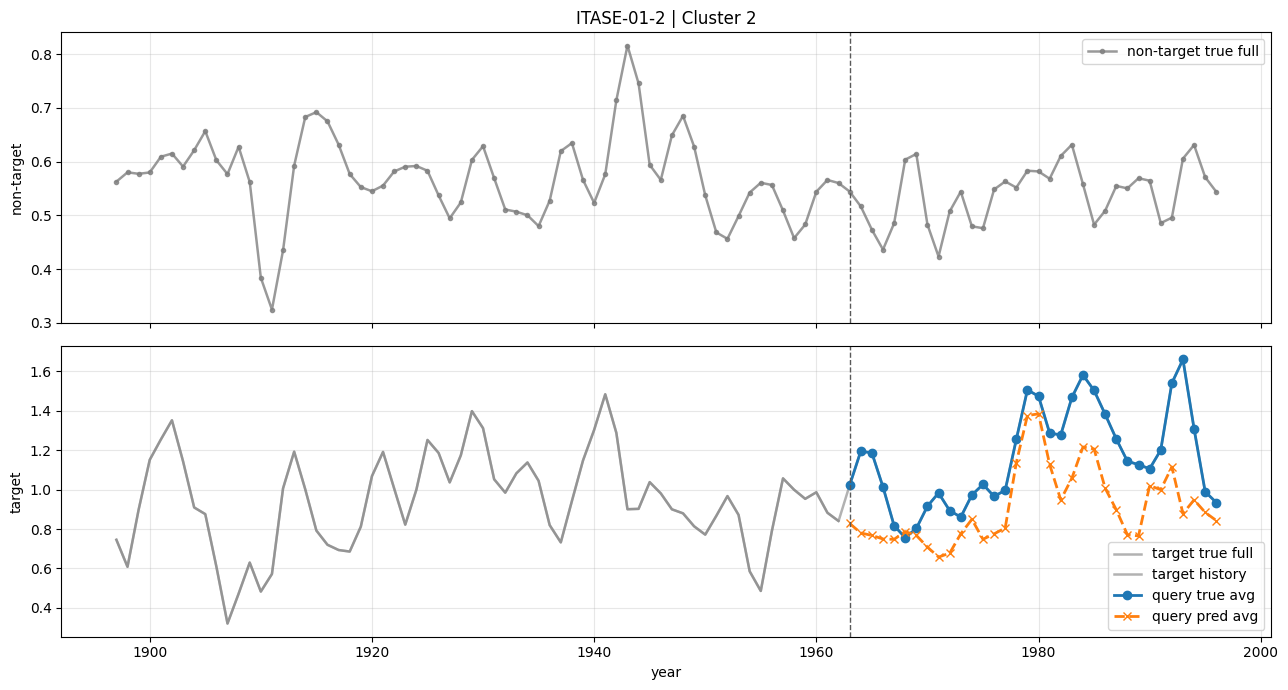

In [7]:
visualise_crossvar_full_series(
    npz_path=str(PROJECT_ROOT / "./results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_relation_pretrain_proto_k3_pair_d0_p1.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    max_sites=5,
)

Loaded results: preds=(12, 32), trues=(12, 32)
Will plot 1 site(s).
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.1114, mae=0.2737, corr=0.5721, corr_smooth_3=0.7143, a3_corr=0.8230, trend_corr=0.1971, direction_acc=54.8%, lag_corr@±2=0.5721, best_lag=0, PeakRecall@10%_±2=0.3333, PeakPrecision@10%_±2=0.3333, PeakF1@10%_±2=0.3333
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.0825, mae=0.2319, corr=0.7058, corr_smooth_3=0.7593, a3_corr=0.8664, trend_corr=0.4341, direction_acc=63.6%, lag_corr@±2=0.7058, best_lag=0, PeakRecall@10%_±2=0.2500, PeakPrecision@10%_±2=0.2500, PeakF1@10%_±2=0.2500


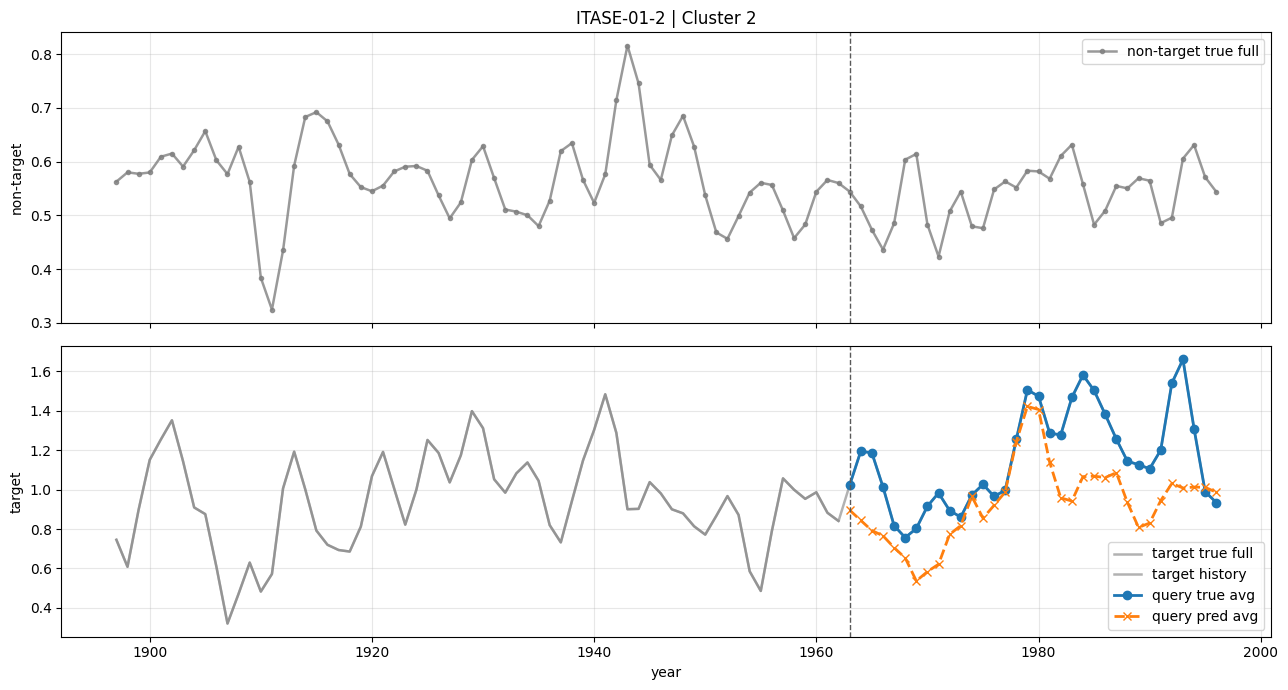

In [15]:
visualise_crossvar_full_series(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    max_sites=5,
)

Loaded results: preds=(12, 32), trues=(12, 32)
Will plot 1 site(s).
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.1301, mae=0.2962, corr=0.5307, corr_smooth_3=0.7428, a3_corr=0.8680, trend_corr=0.1669, direction_acc=59.1%, lag_corr@±2=0.5307, best_lag=0, PeakRecall@10%_±2=0.7500, PeakPrecision@10%_±2=0.7500, PeakF1@10%_±2=0.7500
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.0861, mae=0.2491, corr=0.7636, corr_smooth_3=0.8466, a3_corr=0.9181, trend_corr=0.4060, direction_acc=57.6%, lag_corr@±2=0.7636, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


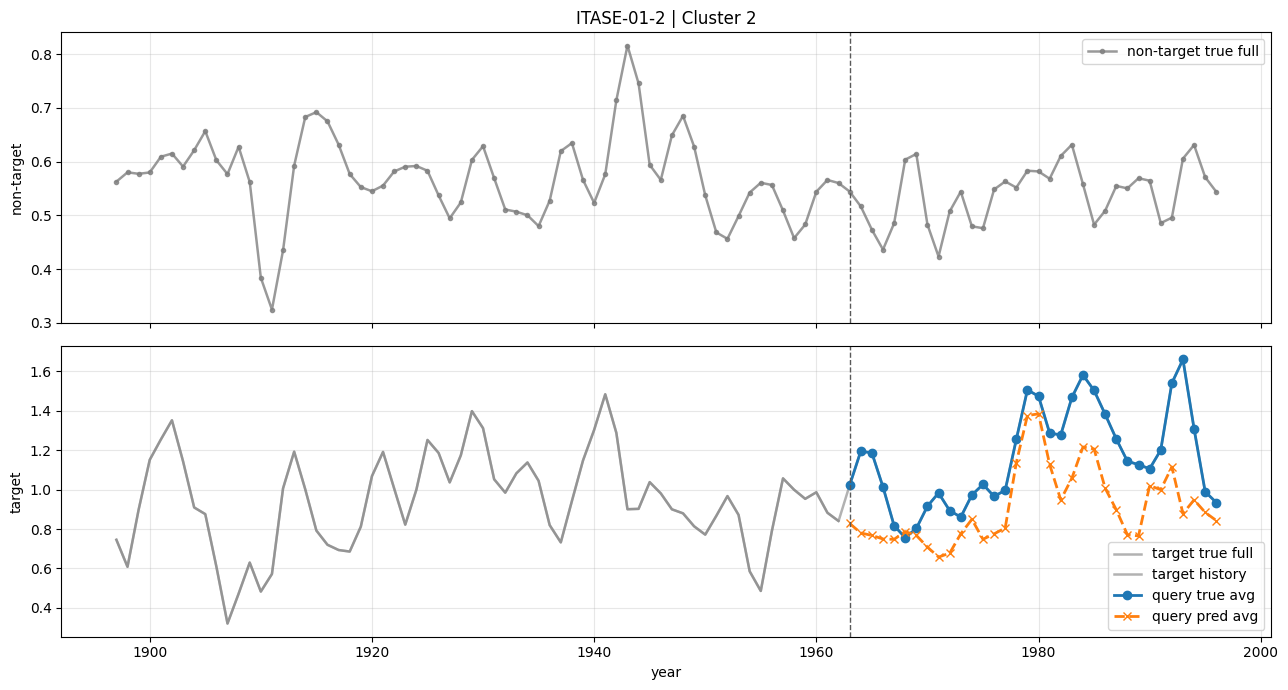

In [16]:
visualise_crossvar_full_series(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_relation_pretrain_proto_k3_pair_d0_p1.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    max_sites=5,
)

Loaded results: preds=(18, 32), trues=(18, 32)
Will plot 3 site(s).
Site ITASE-02-4 pre-aggregation window scaled metrics | mse=0.0994, mae=0.2591, corr=-0.2320, corr_smooth_3=-0.3056, a3_corr=-0.4266, trend_corr=-0.0766, direction_acc=38.7%, lag_corr@±2=-0.0821, best_lag=-2, PeakRecall@10%_±2=0.6667, PeakPrecision@10%_±2=0.6667, PeakF1@10%_±2=0.6667
Site ITASE-02-4 post-aggregation curve scaled metrics | mse=0.0873, mae=0.2440, corr=-0.3162, corr_smooth_3=-0.3578, a3_corr=-0.4044, trend_corr=-0.1348, direction_acc=33.3%, lag_corr@±2=-0.0869, best_lag=-2, PeakRecall@10%_±2=0.7500, PeakPrecision@10%_±2=0.7500, PeakF1@10%_±2=0.7500


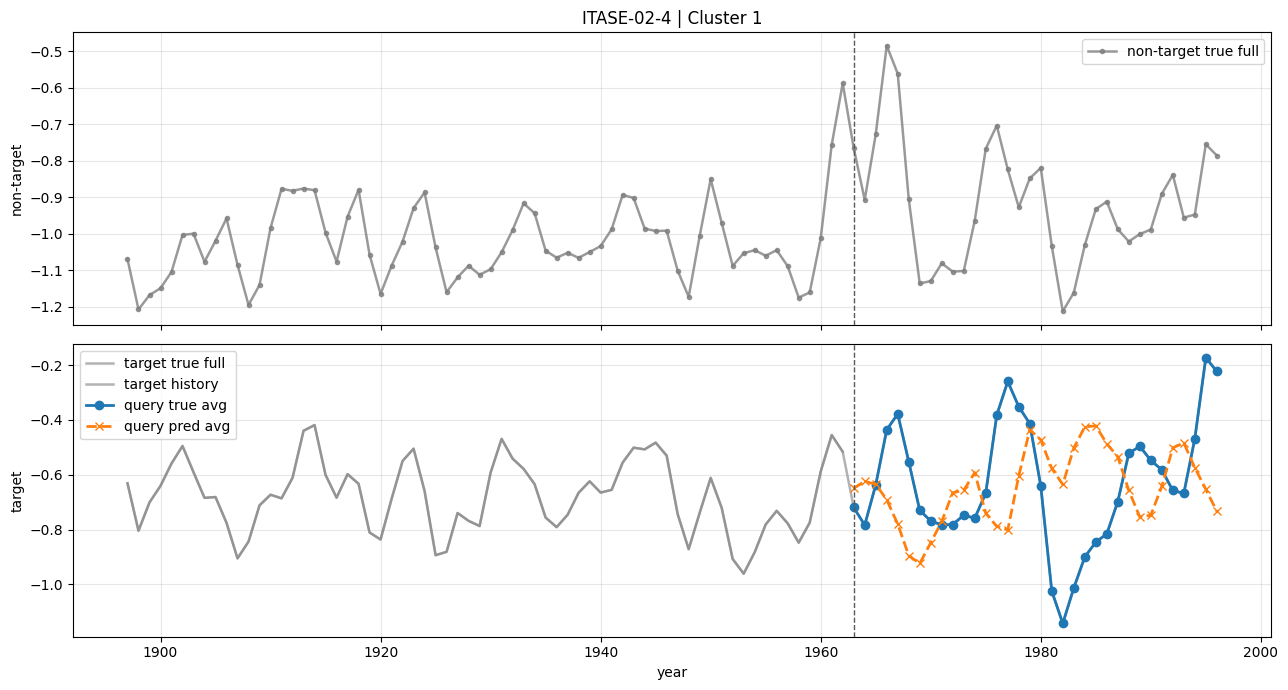

Site Talos Dome 159.07575E pre-aggregation window scaled metrics | mse=0.0710, mae=0.2069, corr=0.1226, corr_smooth_3=0.1785, a3_corr=0.2831, trend_corr=0.0298, direction_acc=47.3%, lag_corr@±2=0.1226, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000
Site Talos Dome 159.07575E post-aggregation curve scaled metrics | mse=0.0488, mae=0.1758, corr=0.1834, corr_smooth_3=0.2049, a3_corr=0.2667, trend_corr=0.0892, direction_acc=60.6%, lag_corr@±2=0.1834, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


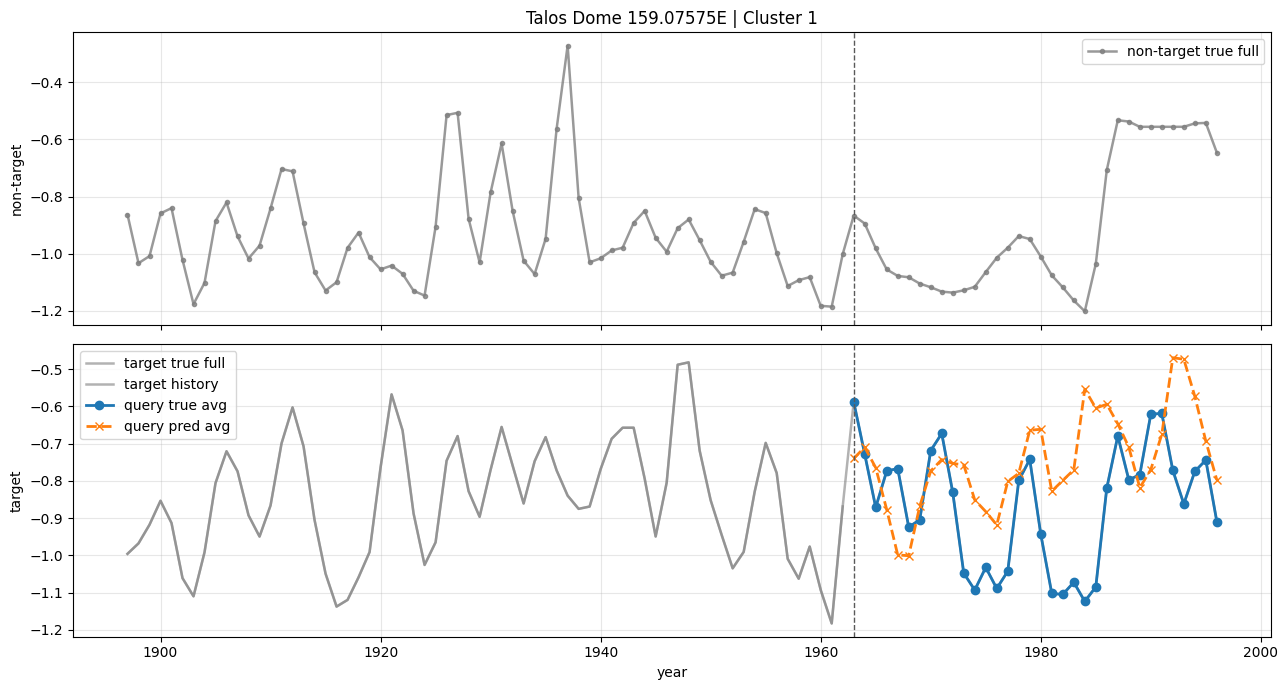

Site FB9814 pre-aggregation window scaled metrics | mse=0.0504, mae=0.1811, corr=-0.1687, corr_smooth_3=-0.3345, a3_corr=-0.5857, trend_corr=0.0398, direction_acc=54.8%, lag_corr@±2=-0.1302, best_lag=-2, PeakRecall@10%_±2=0.4167, PeakPrecision@10%_±2=0.4167, PeakF1@10%_±2=0.4167
Site FB9814 post-aggregation curve scaled metrics | mse=0.0384, mae=0.1537, corr=-0.2044, corr_smooth_3=-0.3620, a3_corr=-0.5996, trend_corr=0.1037, direction_acc=54.5%, lag_corr@±2=-0.1326, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


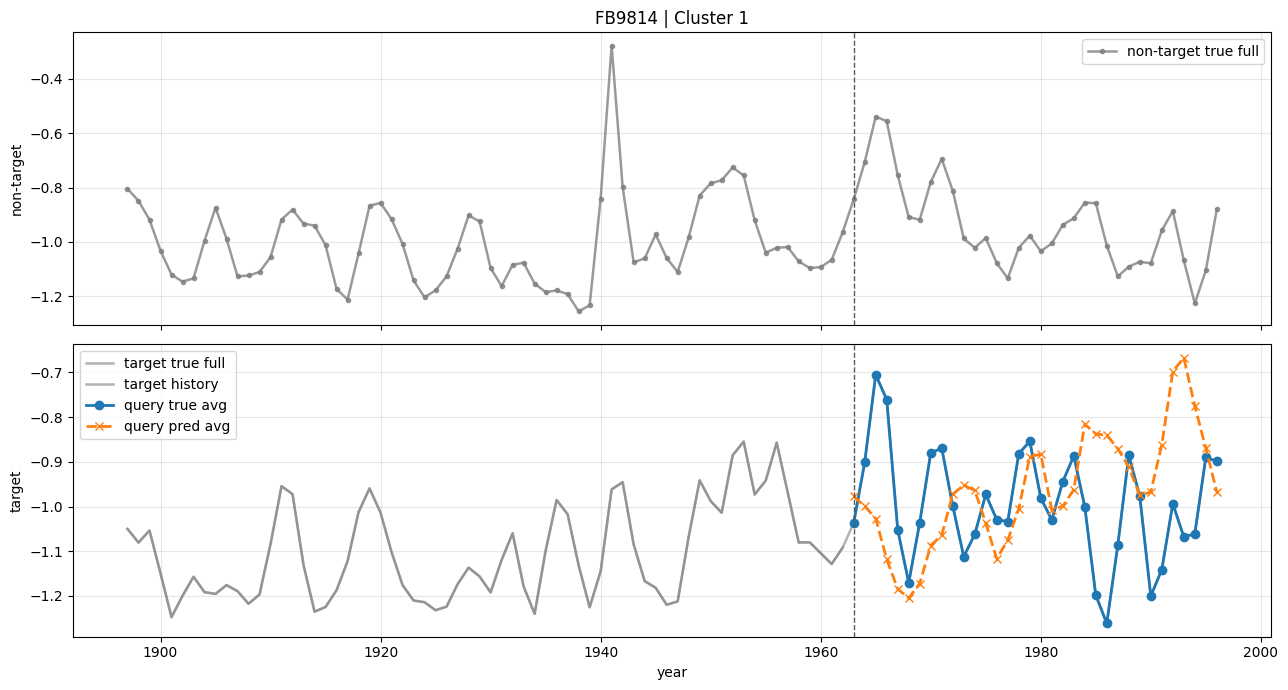

In [34]:
visualise_crossvar_full_series(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_chem_accum_crossvar_protoprototypes/chem_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    max_sites=50,
)

Loaded results: preds=(18, 32), trues=(18, 32)
Will plot 3 site(s).
Site ITASE-02-4 pre-aggregation window scaled metrics | mse=0.0994, mae=0.2591, corr=-0.2320, corr_smooth_3=-0.3056, a3_corr=-0.4266, trend_corr=-0.0766, direction_acc=38.7%, lag_corr@±2=-0.0821, best_lag=-2, PeakRecall@10%_±2=0.6667, PeakPrecision@10%_±2=0.6667, PeakF1@10%_±2=0.6667
Site ITASE-02-4 post-aggregation curve scaled metrics | mse=0.0873, mae=0.2440, corr=-0.3162, corr_smooth_3=-0.3578, a3_corr=-0.4044, trend_corr=-0.1348, direction_acc=33.3%, lag_corr@±2=-0.0869, best_lag=-2, PeakRecall@10%_±2=0.7500, PeakPrecision@10%_±2=0.7500, PeakF1@10%_±2=0.7500


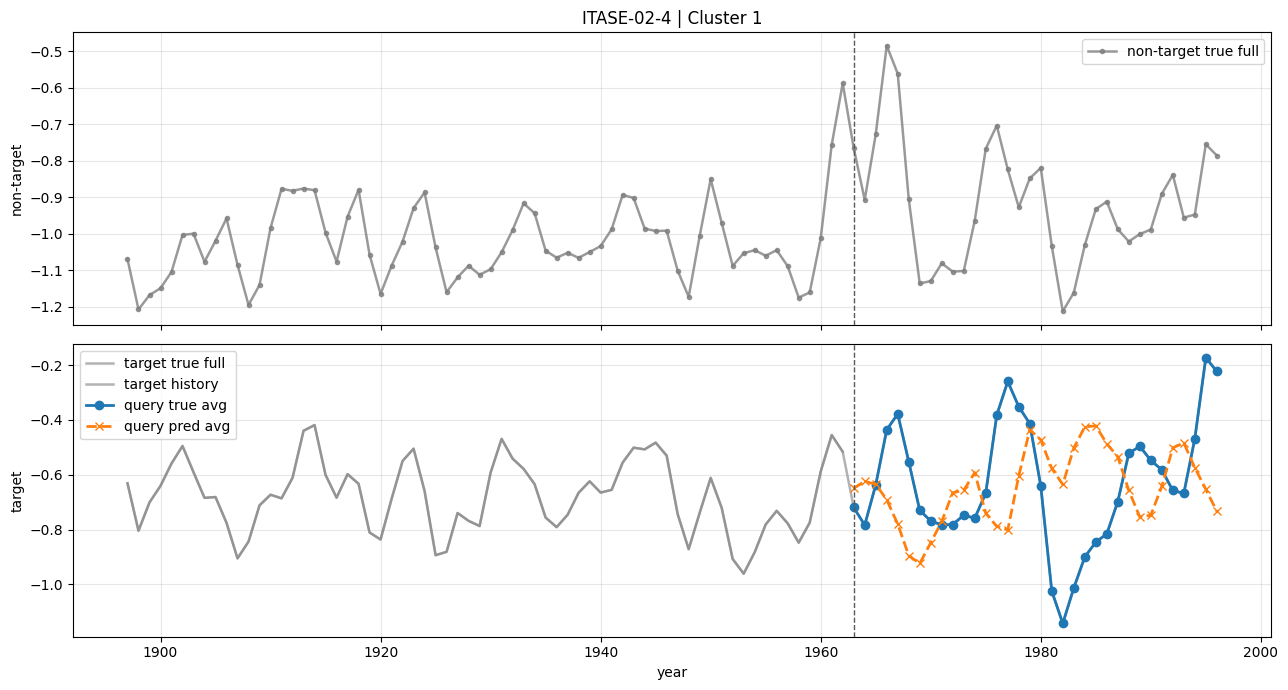

Site Talos Dome 159.07575E pre-aggregation window scaled metrics | mse=0.0710, mae=0.2069, corr=0.1226, corr_smooth_3=0.1785, a3_corr=0.2831, trend_corr=0.0298, direction_acc=47.3%, lag_corr@±2=0.1226, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000
Site Talos Dome 159.07575E post-aggregation curve scaled metrics | mse=0.0488, mae=0.1758, corr=0.1834, corr_smooth_3=0.2049, a3_corr=0.2667, trend_corr=0.0892, direction_acc=60.6%, lag_corr@±2=0.1834, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


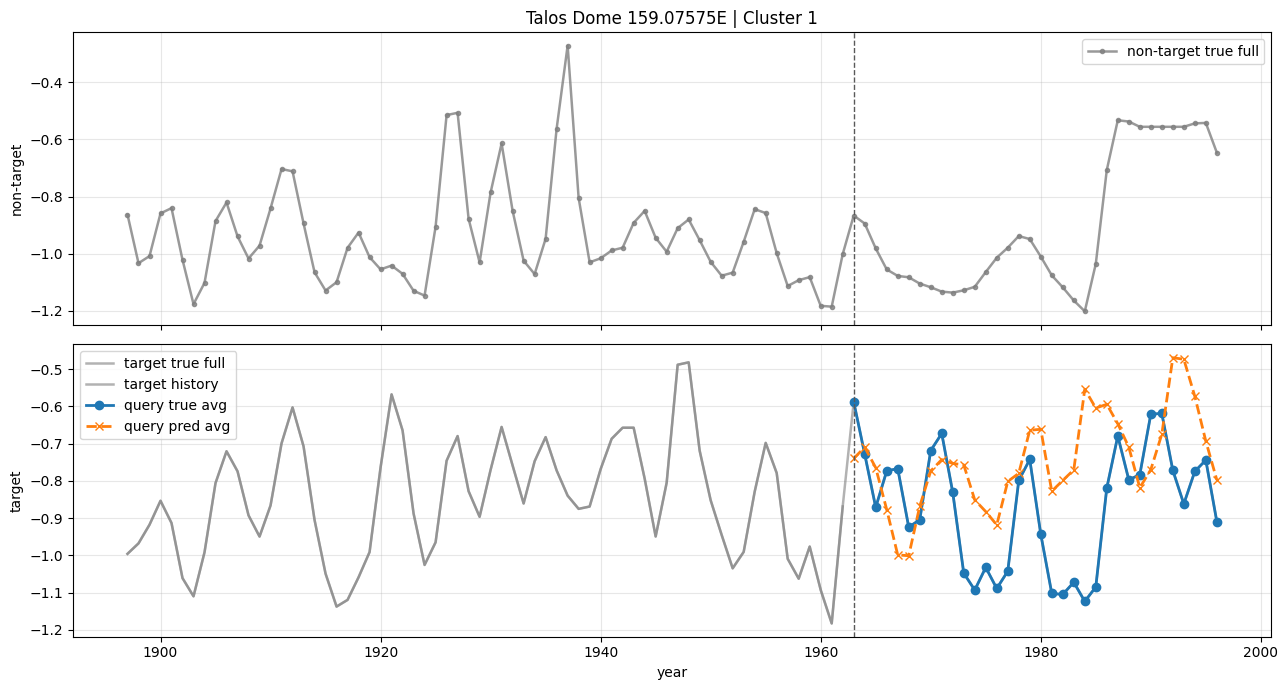

Site FB9814 pre-aggregation window scaled metrics | mse=0.0504, mae=0.1811, corr=-0.1687, corr_smooth_3=-0.3345, a3_corr=-0.5857, trend_corr=0.0398, direction_acc=54.8%, lag_corr@±2=-0.1302, best_lag=-2, PeakRecall@10%_±2=0.4167, PeakPrecision@10%_±2=0.4167, PeakF1@10%_±2=0.4167
Site FB9814 post-aggregation curve scaled metrics | mse=0.0384, mae=0.1537, corr=-0.2044, corr_smooth_3=-0.3620, a3_corr=-0.5996, trend_corr=0.1037, direction_acc=54.5%, lag_corr@±2=-0.1326, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


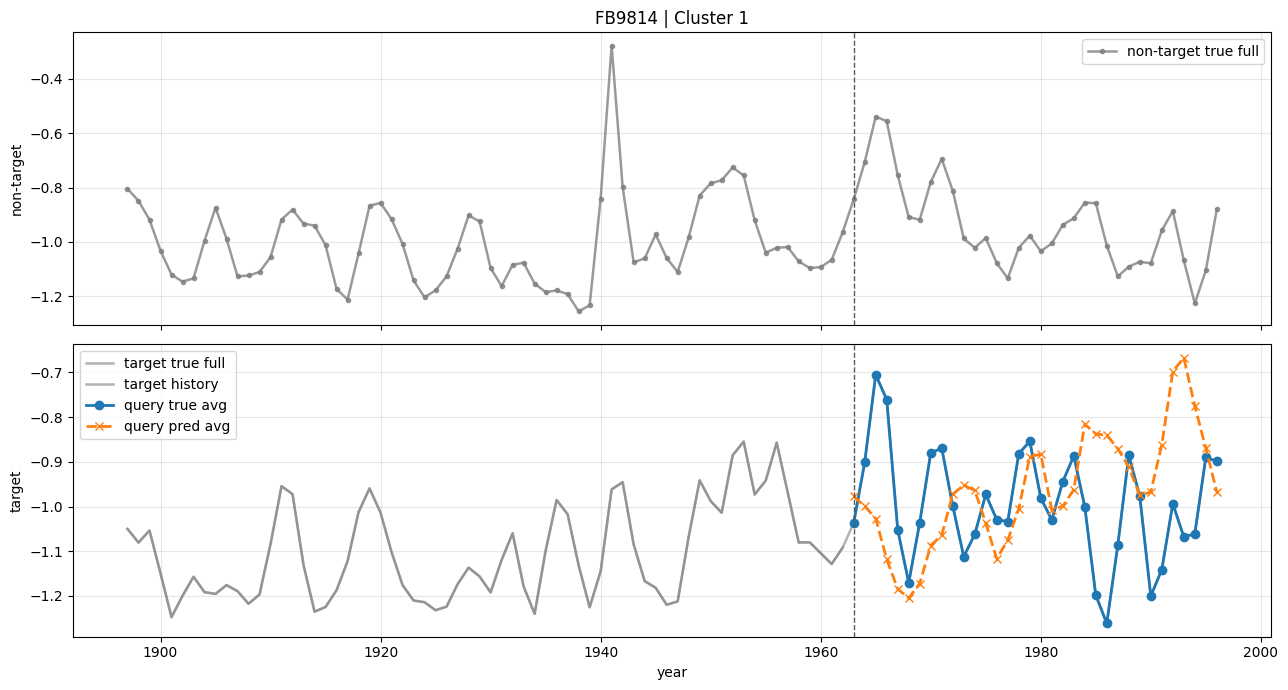

In [ ]:
visualise_crossvar_full_series(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_chem_accum_crossvar_protoprototypes/chem_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    max_sites=50,
)

## CrossVar_zoom

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def visualise_crossvar_query_zoom(
    npz_path,
    target_cluster=None,
    site=None,
    max_sites=5,
):
    """
    CrossVar query zoom version.

    调用方式和 visualise_crossvar_full_series 一致，但只画 query 起点前 16 年 history
    到 query 结束的局部范围，方便肉眼比较 query true / pred。
    """
    history_context = 0
    data = np.load(npz_path, allow_pickle=True)

    required = [
        'preds', 'trues', 'sites', 'years', 'clusters',
        'crossvar_full_sites', 'crossvar_full_x', 'crossvar_full_y',
        'crossvar_full_years', 'crossvar_full_support_lens',
    ]
    missing = [k for k in required if k not in data]
    if missing:
        raise KeyError(
            f"results.npz 缺少 CrossVar 完整序列字段: {missing}。"
            "需要用新版 maml_exp_long_term_forecasting.py 重新跑一次 test。"
        )

    def _squeeze_target_array(arr, name):
        arr = np.asarray(arr)
        if arr.ndim == 3 and arr.shape[-1] == 1:
            return arr[..., 0]
        if arr.ndim == 2:
            return arr
        raise ValueError(f"{name} 应为 [N, T] 或 [N, T, 1]，实际 {arr.shape}")

    def _as_1d_float(arr):
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 2 and arr.shape[-1] == 1:
            arr = arr[:, 0]
        return arr.reshape(-1)

    def _aggregate_window_series(values, start_years):
        values = _squeeze_target_array(values, 'window_values')
        start_years = np.asarray(start_years).reshape(-1)
        if len(values) != len(start_years):
            raise ValueError(f"窗口数量和 years 数量不一致: {values.shape} vs {start_years.shape}")

        sums = {}
        counts = {}
        horizon = values.shape[1]
        for row, start in zip(values, start_years):
            start = float(start)
            for offset in range(horizon):
                if not np.isfinite(row[offset]):
                    continue
                year = start + offset
                sums[year] = sums.get(year, 0.0) + float(row[offset])
                counts[year] = counts.get(year, 0) + 1

        out_years = np.asarray(sorted(sums.keys()), dtype=np.float32)
        out_vals = np.asarray([sums[y] / counts[y] for y in out_years], dtype=np.float32)
        return out_years, out_vals

    def _metric_ready_curve(arr):
        return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)

    preds = _squeeze_target_array(data['preds'], 'preds')
    trues = _squeeze_target_array(data['trues'], 'trues')
    sites = np.asarray(data['sites']).astype(str)
    years = np.asarray(data['years']).reshape(-1)
    clusters = np.asarray(data['clusters']).reshape(-1)

    full_sites = np.asarray(data['crossvar_full_sites']).astype(str)
    full_x = data['crossvar_full_x']
    full_y = data['crossvar_full_y']
    full_years = data['crossvar_full_years']
    support_lens = np.asarray(data['crossvar_full_support_lens']).astype(int)

    selected_sites = list(full_sites)
    if site is not None:
        selected_sites = [s for s in selected_sites if s == site]

    if target_cluster is not None:
        filtered = []
        for s in selected_sites:
            mask = sites == s
            if mask.any() and int(clusters[mask][0]) == int(target_cluster):
                filtered.append(s)
        selected_sites = filtered

    if max_sites is not None:
        selected_sites = selected_sites[:max_sites]

    print(f"Loaded results: preds={preds.shape}, trues={trues.shape}")
    print(f"Will plot {len(selected_sites)} site(s), history_context={history_context} years.")

    for s in selected_sites:
        full_idx_arr = np.where(full_sites == s)[0]
        if len(full_idx_arr) == 0:
            continue
        full_idx = int(full_idx_arr[0])

        x_years = _as_1d_float(full_years[full_idx])
        x_full = _as_1d_float(full_x[full_idx])
        y_full = _as_1d_float(full_y[full_idx])
        support_len = int(support_lens[full_idx])
        support_len = max(0, min(support_len, len(x_years)))
        split_year = x_years[support_len] if support_len < len(x_years) else x_years[-1]

        site_mask = sites == s
        if not site_mask.any():
            continue

        pred_years, pred_vals = _aggregate_window_series(preds[site_mask], years[site_mask])
        true_years, true_vals = _aggregate_window_series(trues[site_mask], years[site_mask])
        cluster_text = int(clusters[site_mask][0]) if len(clusters[site_mask]) > 0 else 'NA'

        zoom_start = split_year - history_context
        if len(true_years) > 0:
            zoom_end = float(max(true_years.max(), pred_years.max()))
        else:
            zoom_end = float(x_years[-1])
        zoom_mask = (x_years >= zoom_start) & (x_years <= zoom_end)

        true_zoom_mask = (true_years >= zoom_start) & (true_years <= zoom_end)
        pred_zoom_mask = (pred_years >= zoom_start) & (pred_years <= zoom_end)

        pre_metrics = _calc_prediction_metrics(preds[site_mask], trues[site_mask])
        _print_site_prediction_metrics(
            s,
            pre_metrics,
            stage="pre-aggregation window scaled metrics",
        )

        post_metrics = _calc_prediction_metrics(
            _metric_ready_curve(pred_vals),
            _metric_ready_curve(true_vals),
        )
        _print_site_prediction_metrics(
            s,
            post_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

        true_gray = 'gray'
        true_blue = '#1f77b4'
        pred_orange = '#ff7f0e'

        axes[0].plot(
            x_years[zoom_mask],
            x_full[zoom_mask],
            color=true_gray,
            linestyle='-',
            marker='.',
            alpha=0.8,
            linewidth=1.8,
            label='non-target true zoom',
        )
        axes[0].axvline(split_year, color='0.35', linestyle='--', linewidth=1.0)
        axes[0].set_ylabel('non-target')
        axes[0].set_title(f'{s} | Cluster {cluster_text} | Query zoom')
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(
            x_years[zoom_mask],
            y_full[zoom_mask],
            color=true_gray,
            linestyle='-',
            alpha=0.6,
            linewidth=1.8,
            label='target history/context',
        )
        axes[1].plot(
            true_years[true_zoom_mask],
            true_vals[true_zoom_mask],
            color=true_blue,
            marker='o',
            linewidth=2,
            label='query true avg',
        )
        axes[1].plot(
            pred_years[pred_zoom_mask],
            pred_vals[pred_zoom_mask],
            color=pred_orange,
            linestyle='--',
            marker='x',
            linewidth=2,
            label='query pred avg',
        )
        axes[1].axvline(split_year, color='0.35', linestyle='--', linewidth=1.0)
        axes[1].set_ylabel('target')
        axes[1].set_xlabel('year')
        axes[1].legend(loc='best')
        axes[1].grid(True, alpha=0.3)

        if np.isfinite(zoom_start) and np.isfinite(zoom_end):
            axes[1].set_xlim(zoom_start, zoom_end)

        fig.tight_layout()
        plt.show()


Loaded results: preds=(18, 32), trues=(18, 32)
Will plot 3 site(s), history_context=0 years.
Site ITASE-02-4 pre-aggregation window scaled metrics | mse=0.0994, mae=0.2591, corr=-0.2320, corr_smooth_3=-0.3056, a3_corr=-0.4266, trend_corr=-0.0766, direction_acc=38.7%, lag_corr@±2=-0.0821, best_lag=-2, PeakRecall@10%_±2=0.6667, PeakPrecision@10%_±2=0.6667, PeakF1@10%_±2=0.6667
Site ITASE-02-4 post-aggregation curve scaled metrics | mse=0.0873, mae=0.2440, corr=-0.3162, corr_smooth_3=-0.3578, a3_corr=-0.4044, trend_corr=-0.1348, direction_acc=33.3%, lag_corr@±2=-0.0869, best_lag=-2, PeakRecall@10%_±2=0.7500, PeakPrecision@10%_±2=0.7500, PeakF1@10%_±2=0.7500


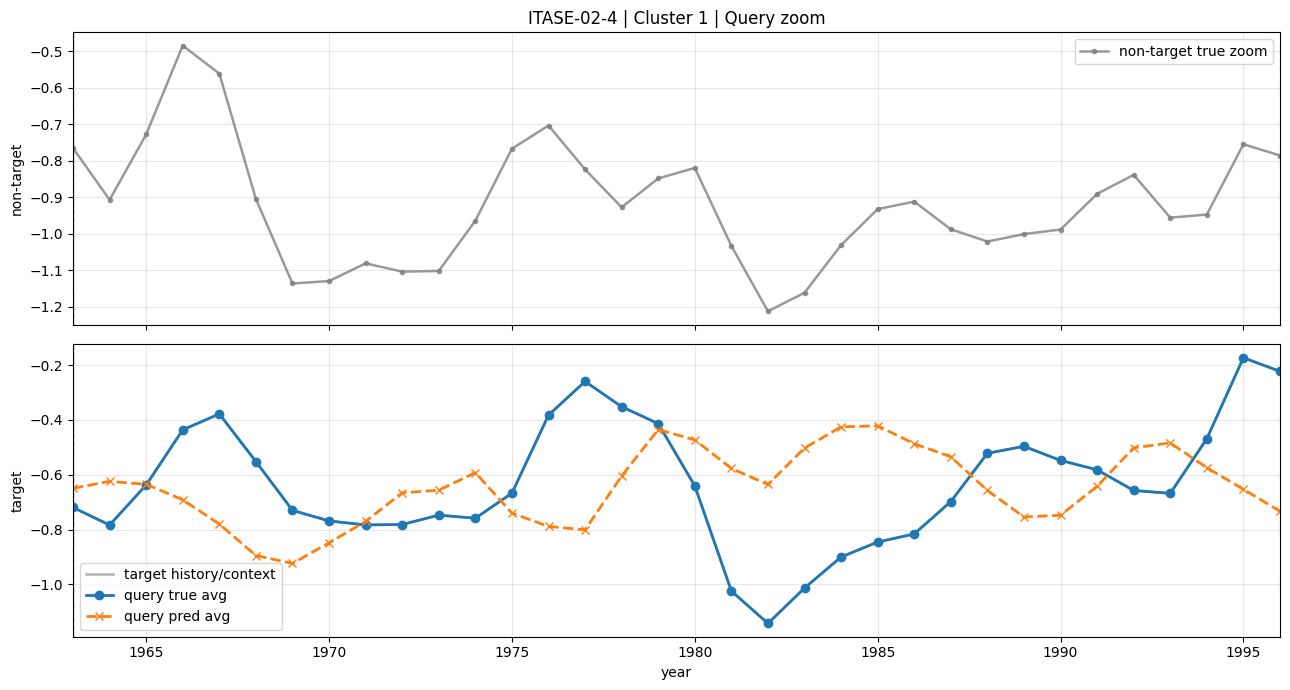

Site Talos Dome 159.07575E pre-aggregation window scaled metrics | mse=0.0710, mae=0.2069, corr=0.1226, corr_smooth_3=0.1785, a3_corr=0.2831, trend_corr=0.0298, direction_acc=47.3%, lag_corr@±2=0.1226, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000
Site Talos Dome 159.07575E post-aggregation curve scaled metrics | mse=0.0488, mae=0.1758, corr=0.1834, corr_smooth_3=0.2049, a3_corr=0.2667, trend_corr=0.0892, direction_acc=60.6%, lag_corr@±2=0.1834, best_lag=0, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


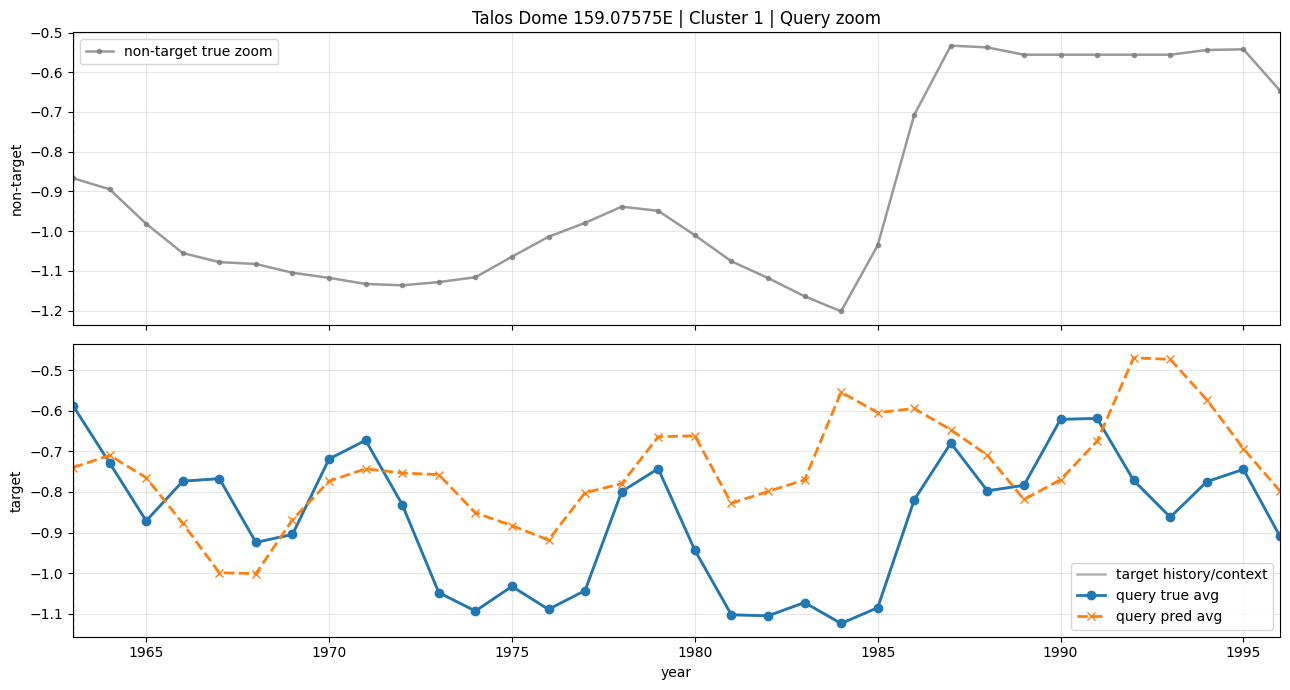

Site FB9814 pre-aggregation window scaled metrics | mse=0.0504, mae=0.1811, corr=-0.1687, corr_smooth_3=-0.3345, a3_corr=-0.5857, trend_corr=0.0398, direction_acc=54.8%, lag_corr@±2=-0.1302, best_lag=-2, PeakRecall@10%_±2=0.4167, PeakPrecision@10%_±2=0.4167, PeakF1@10%_±2=0.4167
Site FB9814 post-aggregation curve scaled metrics | mse=0.0384, mae=0.1537, corr=-0.2044, corr_smooth_3=-0.3620, a3_corr=-0.5996, trend_corr=0.1037, direction_acc=54.5%, lag_corr@±2=-0.1326, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


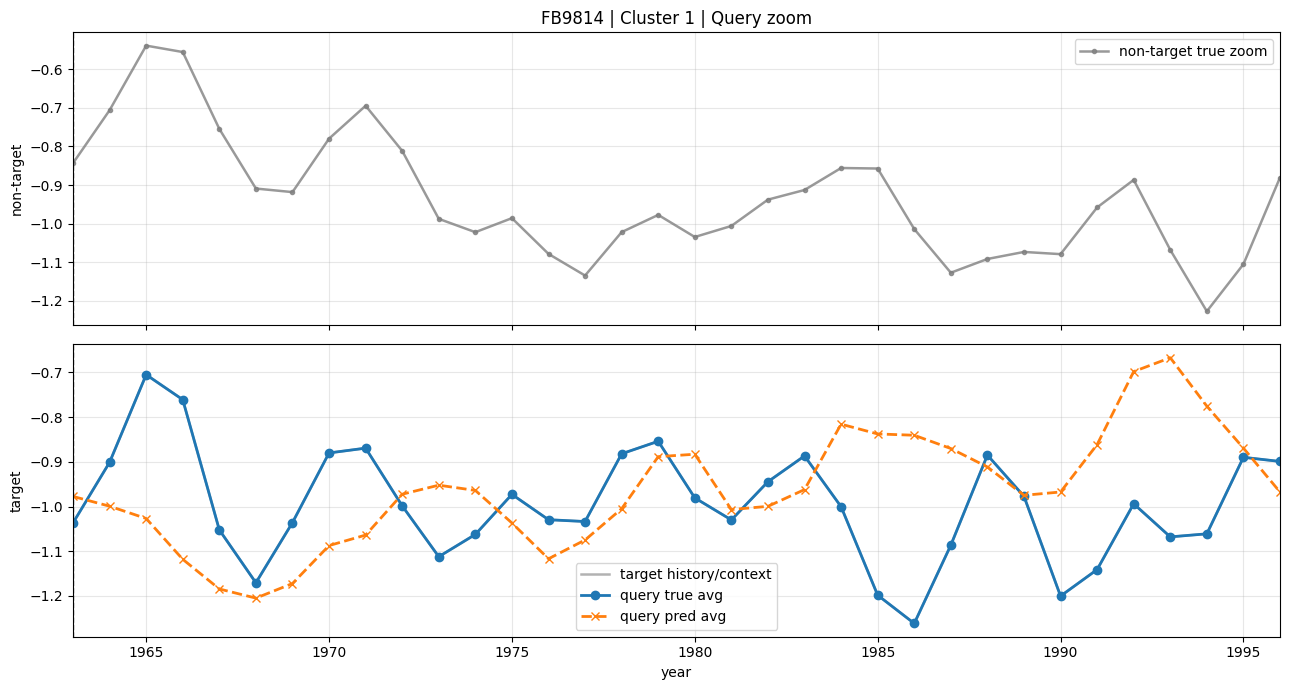

In [18]:
visualise_crossvar_query_zoom(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_chem_accum_crossvar_protoprototypes/chem_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    max_sites=50,
)

Loaded results: preds=(12, 32), trues=(12, 32)
Will plot 1 site(s), history_context=16 years.
Site ITASE-00-1 pre-aggregation window scaled metrics | mse=0.1014, mae=0.2435, corr=-0.2185, corr_smooth_3=-0.2166, a3_corr=-0.0732, trend_corr=-0.1998, direction_acc=45.2%, lag_corr@±2=0.1026, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000
Site ITASE-00-1 post-aggregation curve scaled metrics | mse=0.0873, mae=0.2161, corr=-0.2679, corr_smooth_3=-0.2366, a3_corr=-0.0726, trend_corr=-0.3648, direction_acc=39.4%, lag_corr@±2=0.1269, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


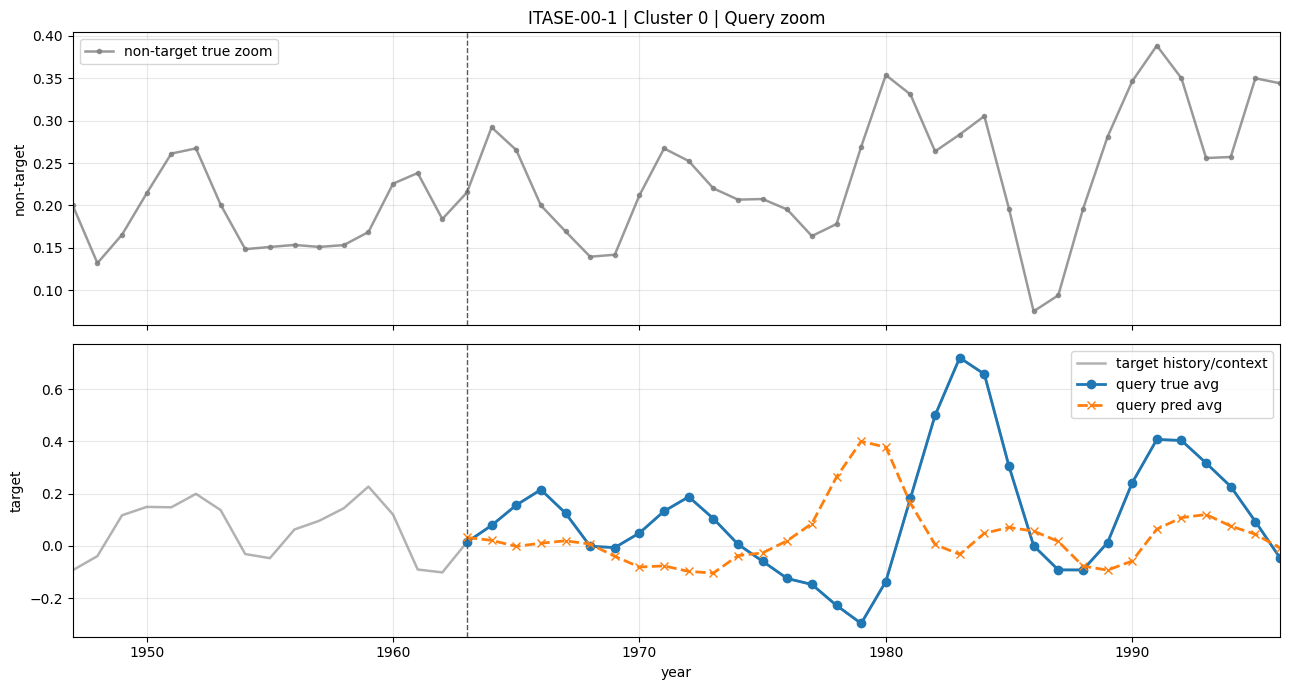

In [13]:
visualise_crossvar_query_zoom(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=0,
    max_sites=5,
)

## MS

- ms / average / inverse_transform

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from data_provider.icecore_data_loader import Dataset_IceCore_MS
from utils.metrics import (
    metric,
    pearson_corr,
    trend_corr,
    direction_accuracy,
    lag_aware_corr,
    smooth_corr,
    a3_corr,
    peak_event_metrics,
)

print("PROJECT_ROOT =", PROJECT_ROOT)

def _to_str_array(arr):
    """
    兼容 npz 里 sites 可能是 bytes / object / str 的情况。
    """
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out)




def _calc_prediction_metrics(pred_values, true_values):
    # 和 test() 使用同一套指标，输入保持为反归一化之前的值。
    # pred_values / true_values: [N, T] 或 [N, T, C]
    pred_values = np.asarray(pred_values)
    true_values = np.asarray(true_values)

    mae, mse, rmse, mape, mspe = metric(pred_values, true_values)
    corr = pearson_corr(pred_values, true_values)
    trend_corr_value = trend_corr(pred_values, true_values)
    direction_acc = direction_accuracy(pred_values, true_values)
    lag_corr, best_lag = lag_aware_corr(pred_values, true_values, max_lag=2)
    corr_smooth_3 = smooth_corr(pred_values, true_values, window=3)
    a3_corr_value = a3_corr(pred_values, true_values)
    peak_recall, peak_precision, peak_f1 = peak_event_metrics(
        pred_values,
        true_values,
        top_ratio=0.1,
        lag_window=2,
    )

    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "mspe": mspe,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "a3_corr": a3_corr_value,
        "trend_corr": trend_corr_value,
        "direction_acc": direction_acc,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "peak_recall_10_lag2": peak_recall,
        "peak_precision_10_lag2": peak_precision,
        "peak_f1_10_lag2": peak_f1,
    }


def _print_site_prediction_metrics(site_name, metrics, stage="metrics"):
    # 打印单个被绘制站点的指标，数值来自反归一化之前的 preds/trues。
    print(
        f"Site {site_name} {stage} | "
        f"mse={metrics['mse']:.4f}, mae={metrics['mae']:.4f}, "
        f"corr={metrics['corr']:.4f}, "
        f"corr_smooth_3={metrics['corr_smooth_3']:.4f}, "
        f"a3_corr={metrics['a3_corr']:.4f}, "
        f"trend_corr={metrics['trend_corr']:.4f}, "
        f"direction_acc={metrics['direction_acc'] * 100:.1f}%, "
        f"lag_corr@±2={metrics['lag_corr']:.4f}, "
        f"best_lag={metrics['best_lag']}, "
        f"PeakRecall@10%_±2={metrics['peak_recall_10_lag2']:.4f}, "
        f"PeakPrecision@10%_±2={metrics['peak_precision_10_lag2']:.4f}, "
        f"PeakF1@10%_±2={metrics['peak_f1_10_lag2']:.4f}"
    )

def _calc_mean_and_sort(data_dict):
    """
    对同一年份的多个样本值求平均，并按年份排序。
    """
    if not data_dict:
        return [], []

    sorted_years = sorted(data_dict.keys())
    mean_vals = [np.mean(data_dict[y]) for y in sorted_years]
    return sorted_years, mean_vals


def _safe_inverse_transform_ms(dataset, vals, var="accum"):
    """
    MS 反归一化。

    var="accum": 使用 accum_scaler
    var="chem": 使用 chem_scaler
    """
    if vals is None or len(vals) == 0:
        return np.array([])

    vals = np.asarray(vals, dtype=np.float32).reshape(-1, 1)
    vals_inv = dataset.inverse_transform(vals, var=var)
    return vals_inv.reshape(-1)

def _normalize_icecore_var_name(name):
    key = str(name).lower().replace("_", "").replace("-", "")
    if "accum" in key:
        return "accum"
    if "chem" in key:
        return "chem"
    if "d18o" in key or "δ18o" in key:
        return "d18O"
    if "dd" in key:
        return "dD"
    return str(name)


def _label_for_ms_var(var_name, var_labels):
    return var_labels.get(var_name, var_name)


def visualise_icecore_ms_with_history(
    npz_path,
    target_cluster,
    root_path,
    x_data_path,
    y_data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    target_var="accum",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    accum_label="Accumulation",
    chem_label="Chem",
    x_label=None,
    y_label=None,
    show=True,
):
    """
    Dataset_IceCore_MS 可视化：单图版本。

    关键点：
    - MS 输入通道顺序由 x_data_path / y_data_path 决定，例如 [d18O, accum]。
    - target_idx 从 Dataset_IceCore_MS.target_idx 读取，和训练时完全一致。
    - accum_label / chem_label 只做旧接口兼容；新组合建议传 x_label / y_label。
    """

    # =========================================================
    # 1. 构造 Dataset_IceCore_MS，用它的 scaler / var_names / target_idx
    # =========================================================
    dataset = Dataset_IceCore_MS(
        root_path=root_path,
        data_path=None,
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="MS",
        target=target_var,
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    var_names = list(dataset.var_names)
    target_var = dataset.target_var
    target_idx = int(dataset.target_idx)

    var_labels = {
        "accum": accum_label,
        "chem": chem_label,
        var_names[0]: x_label or accum_label,
        var_names[1]: y_label or chem_label,
    }
    target_label = _label_for_ms_var(target_var, var_labels)

    # =========================================================
    # 2. 读取 npz
    # =========================================================
    data = np.load(npz_path, allow_pickle=True)

    preds = np.asarray(data["preds"])
    trues = np.asarray(data["trues"])
    sites = _to_str_array(data["sites"])
    years = data["years"]
    clusters = np.asarray(data["clusters"]).reshape(-1)

    has_inputs = "inputs" in data
    inputs = np.asarray(data["inputs"]) if has_inputs else None

    print("preds shape:", preds.shape)
    print("trues shape:", trues.shape)
    if has_inputs:
        print("inputs shape:", inputs.shape)
    print("years shape:", np.asarray(years).shape)
    print("clusters shape:", clusters.shape)
    print(f"MS vars: {var_names} -> target={target_var}, target_idx={target_idx}")

    # =========================================================
    # 3. 只取目标变量，兼容 2D / 3D
    # =========================================================
    # 训练 test() 在 MS 分支通常已经把 preds/trues 切成 [N, pred_len]。
    # inputs 仍是完整 [N, seq_len, 2]，所以 history 必须用 target_idx 切。
    if preds.ndim == 3:
        pred_target = preds[:, :, target_idx]
    elif preds.ndim == 2:
        pred_target = preds
    else:
        raise ValueError(f"Unsupported preds shape: {preds.shape}")

    if trues.ndim == 3:
        true_target = trues[:, :, target_idx]
    elif trues.ndim == 2:
        true_target = trues
    else:
        raise ValueError(f"Unsupported trues shape: {trues.shape}")

    # =========================================================
    # 4. 打印指标
    # =========================================================
    scaled_mse = np.mean((pred_target - true_target) ** 2)
    scaled_mae = np.mean(np.abs(pred_target - true_target))

    preds_flat = pred_target.reshape(-1, 1)
    trues_flat = true_target.reshape(-1, 1)

    preds_inv = dataset.inverse_transform(preds_flat, var=target_var)
    trues_inv = dataset.inverse_transform(trues_flat, var=target_var)

    physical_mse = np.mean((preds_inv - trues_inv) ** 2)
    physical_mae = np.mean(np.abs(preds_inv - trues_inv))

    print("=" * 60)
    print(f"MS task: {var_names} -> {target_var}")
    print(f"Scaled MSE ({target_var}):   {scaled_mse:.6f}")
    print(f"Scaled MAE ({target_var}):   {scaled_mae:.6f}")
    print(f"Physical MSE ({target_var}): {physical_mse:.6f}")
    print(f"Physical MAE ({target_var}): {physical_mae:.6f}")
    print("=" * 60)

    for cid in sorted(np.unique(clusters)):
        mask = clusters == cid
        if not np.any(mask):
            continue

        c_pred = pred_target[mask].reshape(-1, 1)
        c_true = true_target[mask].reshape(-1, 1)

        c_pred_inv = dataset.inverse_transform(c_pred, var=target_var)
        c_true_inv = dataset.inverse_transform(c_true, var=target_var)

        c_mse = np.mean((c_pred_inv - c_true_inv) ** 2)
        c_mae = np.mean(np.abs(c_pred_inv - c_true_inv))

        print(
            f"Cluster {cid}: "
            f"Samples={np.sum(mask):<4} | "
            f"Physical MSE={c_mse:.6f} | "
            f"Physical MAE={c_mae:.6f}"
        )

    print("=" * 60)

    # =========================================================
    # 5. 筛选目标 cluster
    # =========================================================
    target_indices = np.where(clusters == target_cluster)[0]

    if len(target_indices) == 0:
        print(f"No data found for Cluster {target_cluster}.")
        return

    unique_sites = np.unique(sites[target_indices])

    # =========================================================
    # 6. 按站点聚合：同一年份多个样本求平均
    # =========================================================
    for site_name in unique_sites:
        site_mask = (sites == site_name) & (clusters == target_cluster)
        site_idx_list = np.where(site_mask)[0]

        agg_history = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        site_metrics = _calc_prediction_metrics(
            pred_target[site_idx_list],
            true_target[site_idx_list],
        )
        _print_site_prediction_metrics(
            site_name,
            site_metrics,
            stage="pre-aggregation window scaled metrics",
        )

        for idx in site_idx_list:
            year_item = years[idx]
            year_arr = np.asarray(year_item).reshape(-1)

            if len(year_arr) > 1:
                pred_years = year_arr.astype(int)
                first_pred_year = int(pred_years[0])
            else:
                first_pred_year = int(year_arr[0])
                pred_years = np.arange(first_pred_year, first_pred_year + pred_target.shape[1])

            # -------------------------------------------------
            # 6.1 聚合历史输入：只取 target_idx 对应通道
            # -------------------------------------------------
            if has_inputs:
                input_seq = np.asarray(inputs[idx])
                input_len = input_seq.shape[0]
                hist_years = np.arange(first_pred_year - input_len, first_pred_year)
                usable_hist_len = min(len(hist_years), input_len)

                for j in range(usable_hist_len):
                    yr = int(hist_years[j])

                    if input_seq.ndim == 2:
                        hist_val = input_seq[j, target_idx]
                    elif input_seq.ndim == 1:
                        hist_val = input_seq[j]
                    else:
                        raise ValueError(f"Unsupported input_seq shape: {input_seq.shape}")

                    agg_history[yr].append(float(hist_val))

            # -------------------------------------------------
            # 6.2 聚合 true / pred
            # -------------------------------------------------
            y_true_seq = true_target[idx]
            y_pred_seq = pred_target[idx]
            usable_len = min(len(pred_years), len(y_true_seq), len(y_pred_seq))

            for j in range(usable_len):
                yr = int(pred_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        # =====================================================
        # 7. 同一年份样本求平均
        # =====================================================
        hist_years, hist_vals = _calc_mean_and_sort(agg_history)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        post_agg_metrics = _calc_prediction_metrics(
            np.asarray(pred_vals, dtype=np.float32)[None, :],
            np.asarray(true_vals, dtype=np.float32)[None, :],
        )
        _print_site_prediction_metrics(
            site_name,
            post_agg_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        # =====================================================
        # 8. 反归一化
        # =====================================================
        hist_vals_inv = _safe_inverse_transform_ms(dataset, hist_vals, var=target_var)
        true_vals_inv = _safe_inverse_transform_ms(dataset, true_vals, var=target_var)
        pred_vals_inv = _safe_inverse_transform_ms(dataset, pred_vals, var=target_var)

        # =====================================================
        # 9. 单图绘制
        # =====================================================
        plt.figure(figsize=(14, 6))

        if has_inputs and len(hist_years) > 0:
            plt.plot(
                hist_years,
                hist_vals_inv,
                label=f"Aggregated History {target_label}",
                color="gray",
                linestyle="-",
                alpha=0.6,
                linewidth=1.8,
            )

        plt.plot(
            true_years,
            true_vals_inv,
            label=f"Aggregated True {target_label}",
            color="#1f77b4",
            marker="o",
            markersize=4,
            linewidth=2,
        )

        plt.plot(
            pred_years,
            pred_vals_inv,
            label=f"Aggregated Predicted {target_label}",
            color="#ff7f0e",
            linestyle="--",
            marker="x",
            markersize=5,
            linewidth=2,
        )

        plt.title(
            f"Site: {site_name} | Cluster {target_cluster} | MS {target_label} Prediction",
            fontsize=14,
            pad=10,
        )
        plt.xlabel("Year", fontsize=12)
        plt.ylabel(target_label, fontsize=12)
        plt.legend(loc="best", fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if show:
            plt.show()
        else:
            plt.close()


PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy


preds shape: (165, 16)
trues shape: (165, 16)
inputs shape: (165, 32, 2)
years shape: (165, 16)
clusters shape: (165,)
MS task: [accum, chem] -> chem
Scaled MSE (chem):   0.249305
Scaled MAE (chem):   0.338338
Physical MSE (chem): 3945426.500000
Physical MAE (chem): 1345.958862
Cluster 0: Samples=66   | Physical MSE=5724856.000000 | Physical MAE=1748.159790
Cluster 1: Samples=66   | Physical MSE=333142.187500 | Physical MAE=453.929565
Cluster 2: Samples=33   | Physical MSE=7611137.000000 | Physical MAE=2325.615479


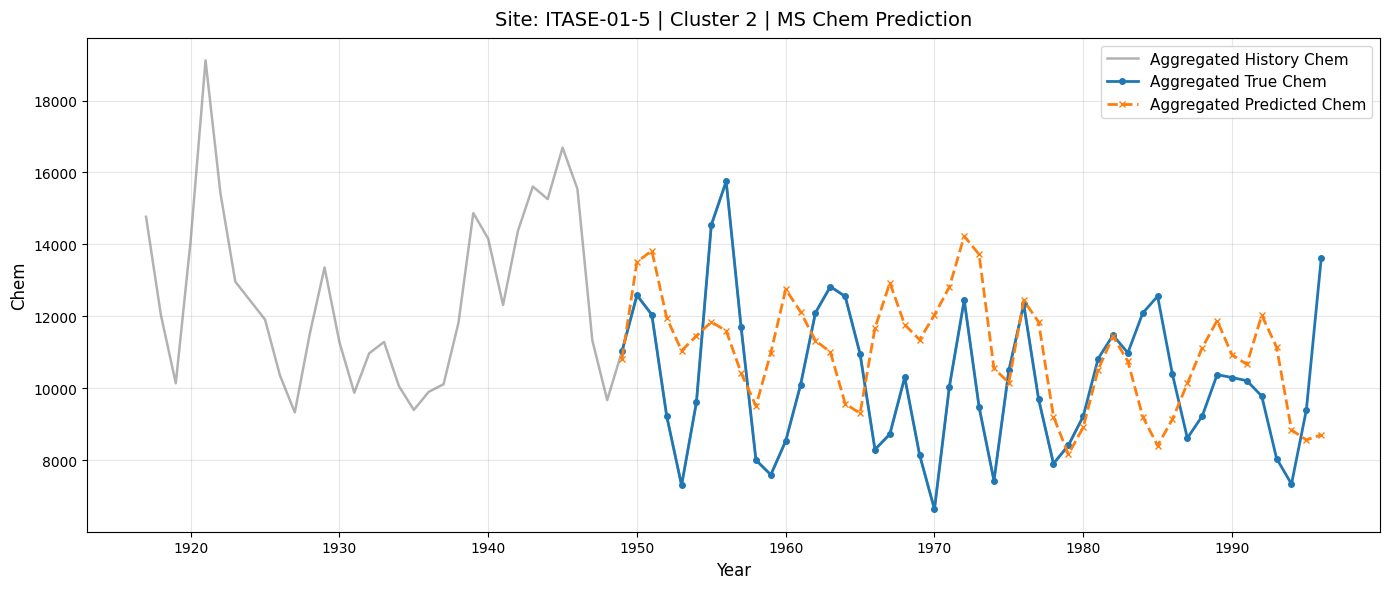

In [37]:
visualise_icecore_ms_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_chem_ms_ftMS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="accum/accum_100y.csv",
    y_data_path="chem/chem_clean.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/chem_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    target_var="chem",
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    accum_label="Accumulation",
    chem_label="Chem",
    show=True,
)

preds shape: (132, 16)
trues shape: (132, 16)
inputs shape: (132, 32, 2)
years shape: (132, 16)
clusters shape: (132,)
MS vars: ['d18O', 'accum'] -> target=accum, target_idx=1
MS task: ['d18O', 'accum'] -> accum
Scaled MSE (accum):   0.082852
Scaled MAE (accum):   0.187052
Physical MSE (accum): 3949.542236
Physical MAE (accum): 40.839825
Cluster 0: Samples=33   | Physical MSE=5145.656250 | Physical MAE=53.278824
Cluster 1: Samples=66   | Physical MSE=417.641510 | Physical MAE=15.503699
Cluster 2: Samples=33   | Physical MSE=9817.229492 | Physical MAE=79.073082
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.2059, mae=0.3622, corr=0.0005, corr_smooth_3=-0.0055, a3_corr=0.0545, trend_corr=-0.0286, direction_acc=55.8%, lag_corr@±2=0.1245, best_lag=1, PeakRecall@10%_±2=0.3788, PeakPrecision@10%_±2=0.3788, PeakF1@10%_±2=0.3788
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.1743, mae=0.3252, corr=0.2840, corr_smooth_3=0.4092, a3_corr=0.6917, trend_corr=-0.0512, d

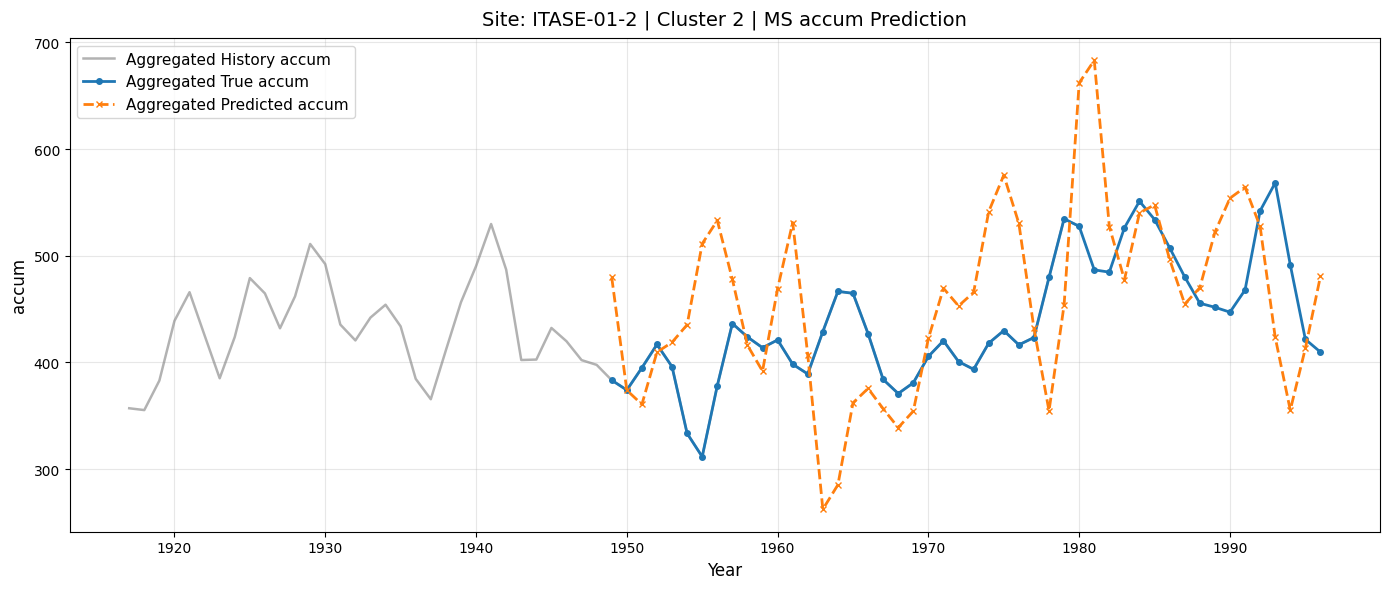

In [13]:
visualise_icecore_ms_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_ms_ftMS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="d18O/d18O_clean.csv",
    y_data_path="accum/accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    target_var="accum",
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    accum_label="d18O",
    chem_label="accum",
    show=True,
)